# Robustness Sweeps for Lag-Context Learning Rules

Companion to `hetero_rules_run.ipynb`, which introduces the update rule, the catalogue and the
crossover benchmark. Nothing is re-derived here.

## Contents

| § | sweep | axis | $\omega$ |
|---|---|---|---|
| **1** | Corruption ratio | $\rho$, 0.05 - 0.35 | $\omega \equiv 0.05$ |
| **2** | Network size | $N$, 20 - 400 | $\omega \equiv 0.05$ |
| **2b** | Network size, $L_{\max}$-style measure | $N$, 50 - 500 | $\omega \equiv 0.05$ |
| **2c** | Scaling $\omega$ with $N$ | $N \times \sigma_\omega$ grid | $\sigma_\omega$ **swept**, 0.05 - 0.45 |
| **3** | Superposition of learning rules | mixing weight $w$ | $\omega \equiv 0.05$ |
| **4** | Crossover geometries | four branching topologies | $\omega \equiv 0.05$ |
| **5** | Settle vs. loop | `boundary` | $\omega \equiv 0.05$ |
| **6** | Frequency conditions | $\omega \equiv 0$ (displaced start), $\omega \equiv 1$ | $\sigma_\omega = 0$ |
| **7** | Random (uncorrelated) patterns | -- | $\omega \equiv 0.05$ |

Preceded by: *Configuration*, *The learning rules*, *The success metrics*, and a duration /
`margin` check (also $\omega \equiv 0.05$).

**On $\omega$.** This notebook runs the **constant-frequency regime**: `CONFIG` sets
`frequency_mean = 0.05`, `frequency_std = 0.0`, so every oscillator carries the *same* settable
intrinsic frequency and there is no quenched disorder anywhere. Two assertions at the top
enforce it.

$\omega$ is not a gauge choice here. Unlike standard Kuramoto, where a uniform $\omega$ is
removable by a rotating frame because the coupling depends only on phase differences, the drive
$\dot\theta_i = \omega_i - \sin\theta_i V_i(\cos\theta)$ is anchored to the stored patterns on
the $\{0,\pi\}$ lattice. A uniform $\omega$ therefore rotates the state *relative to the
memories*, and its job is to break the fixed-point degeneracy at the cue -- where
$\sin\theta_i = 0$ and the coupling alone cannot move anything.

`hetero_rules_run.ipynb` §8 measures the response: $\omega = 0$ is singular (an exact fixed
point, not a slow limit), there is a **ceiling rather than a peak** above which the drift
competes with the coupling, and a rate limit near $\omega \approx 0.01$ below which the escape
outlasts the duration. That leaves a usable band of roughly $[0.02, 0.2]$; **0.05** is the
operating point used throughout here. §2c sweeps $\omega$ against $N$; §6 visits the two edges
of the band. `phase_noise = 0.01` is inert because `mode = "ode"`.

## What is measured

**Rules** -- the nine of `hetero_rules_run.ipynb`, all $d = 3$: `self`, `forward`, `skip-two`,
`self+forward`, `forward+skip2`, `bigram`, `multilag`, `coh bigram`, `coh trigram`.

**Topologies** -- a single smooth chain of `SEQ_LEN = 9` (10 patterns) for sweeps 1, 2, 3, 6;
independently random patterns for sweep 7; and four two-branch crossovers for sweep 4:

| tag | spec | $P$ | shared | $L$ |
|---|---|---|---|---|
| `2-1-2` | **(a)** eq (7) | 5 | $\{2\}$ | 1 |
| `2-2-2` | **(c)** eq (9) | 6 | $\{2,3\}$ | 2 |
| `2-3-2` | failure case | 7 | $\{2,3,4\}$ | 3 |
| `1-1-1` | legacy | 3 | $\{1\}$ | 1 |

All chains are **smooth**: consecutive patterns differ by $\rho N$ flips, overlap $1 - 2\rho$.

**Metrics** -- for single-sequence retrieval:

1. **Retrieval fraction** (primary) -- peaks correctly retrieved **in order before the first
   failure**, as a share of the sequence: `compare_to_stored_sequence(retrieved, seq) / P`.
   `kuramoto_sequence.ipynb`'s measure. Partial credit, so a rule recovering 9 of 10 reads as
   90% rather than as total failure, and it resolves *how far* a rule gets. Reported with its
   standard deviation (`fraction_std`). The spread is taken
   over trials, i.e. across generated chains, and is reported everywhere the mean is -- as a
   band in §1/§2/§3, error bars in §6/§7, and printed next to the mean in the tables and on
   the §2c grid. It separates a rule that stalls at the same place on every chain from one
   that is bimodal, which the mean alone hides.
2. **Strict full-retrieval rate** (secondary) -- the fraction of trials scoring exactly 100% on
   metric 1. Kept in the printed tables; the plots show metric 1.
3. **Overlap quality** -- for a *fully* retrieved trial, the mean over its patterns of each
   one's *peak* overlap, averaged over those trials only. A rule can be reliable and sloppy, or
   rare and crisp.

**Which "retrieval"?** Metrics 1 and 2 answer different questions and their keys differ by one
word, so read the key, not the label:

| key | question | denominator |
|---|---|---|
| `retrieval_fraction` | how much **of a** sequence came back | per trial, `reached / P`, then meaned over trials; spread as `fraction_std` |
| `retrieval_rate` | how many **of the** sequences came back whole | trials scoring exactly 1.0, over trials |
| §2b right panel | same, relaxed to 90% | seeds with fraction $\geq$ `RETRIEVAL_TOLERANCE` |

Nearly every *plot* here shows metric 1; metric 2 lives in the printed tables beside it. Two
things to keep in mind when reading metric 1: position 0 is the cue, which
`compare_to_stored_sequence` counts, so **1/P is the floor** and no rule scores below it -- the
`self` rule scores exactly the floor and is the control for that. And a rule that transitions
*wrongly* is scored below one that does not transition at all, since the match is a prefix:
`skip-two` decodes `0,2,4,...` and breaks at step 1.

§4 reuses the key `retrieval_rate` for a different measurement -- strict `classify_unshared`
success over *cueing attempts*, two per trial -- so its denominator is `2 x trials`.

Crossover sweeps (§4, §5) keep the strict criterion: there the question is whether the
trajectory commits to the right branch, which has no natural partial credit.

`zeroed()` plots an undefined metric 3 (no fully-retrieved trial) as a literal `0.0`, so a rule
that fails reads as a flat zero line rather than one that stops mid-axis.

In [7]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import itertools

import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path


# Walk up from the working directory to whichever ancestor actually contains the `kuramoto`
# package, rather than assuming the kernel was started in kuramoto/hetero_learning/.
# Path.cwd().parent.parent is only correct from that one directory; from the repo root, or
# from anywhere else, it points outside the project and the import below fails.
root_dir = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "kuramoto").is_dir()),
                Path.cwd())
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import kuramoto.kuramoto_library as krm
import kuramoto.hetero_learning.kuramoto_hetero as kc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

`SEQ_LEN = 9` (10 patterns), nearly twice `hetero_rules_run.ipynb`'s length. Integration time
scales with it -- `DWELL_PER_TRANSITION * seq_len` at **20.0 per transition**, so $T = 180$
here. That is the same dwell `CROSSOVER_GEOMETRIES` already uses (every entry there is exactly
$20 \times$ `seq_len`); the single-sequence path previously ran at `CONFIG["T"] / 5 = 6.0`, so
the two halves of the notebook now agree.

The headroom is deliberate and is *not* fitted to anything. Measured at $\omega \equiv 0.05$,
the outcomes are **bit-identical from $T = 54$ to $T = 450$** -- on the default chain, at
$N = 400$, and at $\rho = 0.30$ -- because the trajectories reach the stationary early-stop far
inside the shortest. Longer durations therefore cost almost no wall-clock, since the
integration returns as soon as it settles. This notebook is the one that runs the long chains;
`hetero_rules_run.ipynb` is capped at 80.0 and is unaffected.


In [8]:
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_mean=0.05,   # OMEGA_OPT -- constant, identical for every oscillator
    frequency_std=0.0,     # no disorder anywhere in this notebook
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.5,
    mode="ode",
)

N = 100

# Online-decoder hysteresis. Lowered from 0.01: on a long mutation chain the gaps between
# neighbouring patterns' overlaps are ~0.003, an order of magnitude under the old value.
MARGIN = 0.001
SEED_POOL = 10_000
SINGLE_SEQ_TRIALS = 100

SEQ_LEN = 9                             # 10 stored patterns per single-sequence trial
# 20.0 per transition. This is the dwell CROSSOVER_GEOMETRIES below already uses -- every
# one of its entries is exactly 20.0 * seq_len -- so the single-sequence path now matches it
# instead of running at CONFIG["T"]/5 = 6.0. At SEQ_LEN = 9 that is a duration of 180.
#
# Deliberately generous, not fitted: measured at omega = 0.05 the outcomes are BIT-IDENTICAL
# from T = 54 to T = 450 on the default chain, at N = 400 and at rho = 0.30 -- the trajectories
# hit the stationary early-stop far inside the shortest. The headroom therefore costs almost no
# wall-clock (the integration exits when settled) and covers the harder corners of the sweeps.
DWELL_PER_TRANSITION = 20.0

# The regime this notebook now runs in: a settable, uniform intrinsic frequency.
# omega must be non-zero -- at an exact cue every phase is on the {0, pi} lattice where
# sin(theta) = 0, so with omega = 0 the drive vanishes identically and the cue is an exact
# fixed point. omega is what breaks that degeneracy; see hetero_rules_run.ipynb §8.
# It must also clear ~0.01, below which the escape is slow enough to outlast the duration.
OMEGA = CONFIG["frequency_mean"]
assert CONFIG["frequency_std"] == 0.0, "this notebook is the constant-omega regime"
assert OMEGA != 0.0, "omega = 0 is an exact fixed point at an exact cue"


## The learning rules

Unchanged from `hetero_rules_run.ipynb`. `GAIN_CATALOGUE` is the same nine through
`kc.proportional_gain`, which removes the $(1-2\rho)^{\sum \text{lags}}$ handicap a lag-heavy
gate carries. Sweeps 1, 2 and 2b run both -- at $P = 10$ that correction decides whether the
context rules retrieve at all.


In [9]:
RAW_CATALOGUE = {
    "self":          kc.self_rule(),
    "forward":       kc.forward_rule(),
    "skip-two":      kc.skip_rule(nhop=2),
    "self+forward":  kc.mixture(kc.self_rule(weight=0.3), kc.forward_rule(weight=1.0)),
    "forward+skip2": kc.mixture(kc.forward_rule(weight=1.0), kc.skip_rule(2, weight=0.5)),
    "bigram":        kc.bigram_rule(),
    "multilag":      kc.multilag_rule((1.0, 1.0, 1.0)),
    "coh bigram":    kc.coherent_bigram_rule(),
    "coh trigram":   kc.coherent_trigram_rule(),
}

# The same rules through kc.proportional_gain, which divides each term by
# (1 - 2*rho)^(sum of its lags) and the rule by its total weight, so every rule has total
# gate 1 at its own operating point. The N sweeps below run both, because at this sequence
# length the difference between them is the whole result -- see section 2.
GAIN_CATALOGUE = {name: kc.proportional_gain(rule, CONFIG["corruption_rate"])
                  for name, rule in RAW_CATALOGUE.items()}


In [10]:
def mean_overlap_score(result, seq):
    """METRIC 2 -- mean, over every non-cue pattern in `seq`, of that pattern's PEAK overlap,
    from an already-computed simulate() result. Only meaningful for a correctly retrieved
    trial -- callers must check that separately (see single_sequence_score_sweep)."""
    return float(result["overlaps"][:, 1:].max(axis=0).mean())


def zeroed(values):
    """nan -> 0.0.  `mean_overlap` is nan when a rule had no successful trial to average;
    plotting nan leaves a gap and the line ends abruptly mid-axis. A rule that never
    retrieves anything should read as a flat zero, which is what it scored."""
    return [0.0 if v != v else float(v) for v in values]


def band(ax, x, means, stds, **kw):
    """Draw metric 2 as a line with a +/- 1 standard-deviation band -- the spread of overlap
    quality across the successful trials."""
    means, stds = np.asarray(zeroed(means)), np.asarray(zeroed(stds))
    line, = ax.plot(x, means, "-o", **kw)
    ax.fill_between(x, means - stds, means + stds, color=line.get_color(), alpha=0.12, lw=0)
    return line


def generate_random_sequence(N, seq_len, name, seed):
    """A sequence of seq_len+1 INDEPENDENTLY random patterns -- no mutation chain, unlike
    generate_sequence, so consecutive patterns are unrelated rather than similar."""
    rng = np.random.default_rng(seed)
    patterns = [rng.choice([0.0, np.pi], size=N) for _ in range(seq_len + 1)]
    return krm.sequence_from_patterns(name, patterns)


def displaced_cue(seq, corruption_rate, phase_jitter, rng):
    """theta(0) for the omega = 0 runs: a displacement of the zeroth stored pattern.

    The displacement is NOT a stored pattern -- it is never added to `seq` and never
    memorised, it is only where the trajectory starts. Two parts:

      - `corruption_rate` neurons flipped 0 <-> pi, the same corruption operator the
        mutation chain is built from;
      - `phase_jitter`, a small uniform angular nudge on every neuron.

    The jitter is what makes the displacement effective. `corrupt_phase` keeps every phase
    on the {0, pi} lattice, where sin(theta) = 0 exactly -- so at omega = 0 the drive
    vanishes identically and a flip-only displacement is still an exact fixed point. The
    angular nudge takes theta off the lattice so sin(theta) != 0 and the dynamics can run."""
    theta = krm.corrupt_phase(seq[0], corruption_rate, rng)
    if phase_jitter > 0:
        theta = theta + rng.uniform(-phase_jitter, phase_jitter, size=theta.shape[0])
    return theta


def run_single_trial(net, seq, duration, boundary=None, cue_corruption_rate=0.0,
                     cue_phase_jitter=0.0, rng=None):
    """One integration, returning a simulate()-shaped result dict.

    With no displacement this is just `net.simulate`. With one, the cue is built by
    `displaced_cue` and handed to `net._integrate` directly, since `net.simulate` always
    constructs an exact, uncorrupted cue."""
    if cue_corruption_rate > 0 or cue_phase_jitter > 0:
        theta_init = displaced_cue(seq, cue_corruption_rate, cue_phase_jitter, rng)
        theta_history, time = net._integrate(seq, theta_init, None, None, duration, boundary)
        return {"time": time, "theta_history": theta_history, "cue": (seq.name, 0),
                "overlaps": net.overlaps(theta_history, seq)}
    return net.simulate(seq, T=duration, boundary=boundary)


def single_sequence_score_sweep(catalogue, seq_len, corruption_rate, N, trials=SINGLE_SEQ_TRIALS,
                                seed=0, boundary=None, config_overrides=None,
                                cue_corruption_rate=0.0, cue_phase_jitter=0.0,
                                random_patterns=False, duration=None):
    """For each rule, run `trials` freshly generated single sequences of size `N` and report:
      - retrieval_fraction / fraction_std: METRIC 1, the mean over trials of
        `compare_to_stored_sequence(retrieved, seq) / len(seq)` -- the share of the sequence
        recovered, in order, before the first failure. Partial credit; 1.0 means full recall.
        The spread is over trials, i.e. across generated chains -- it says whether a rule is
        uniformly mediocre or bimodal (some chains fully recalled, others dropped early).
      - retrieval_rate: METRIC 2, the STRICT rate -- the fraction of trials scoring exactly
        1.0 on metric 1.
      - mean_overlap / overlap_std / overlap_var: METRIC 3, mean_overlap_score over ONLY the
        fully-retrieved trials, and its spread (nan if none -- plot via `zeroed`).
      - n_correct: how many trials the metric-3 statistics are averaged over.

    Decoded with `decode_sequence_online`: a pattern counts as retrieved only while it is
    the closest stored pattern to the state. A pattern whose own overlap peaks while some
    other pattern sits higher is a mixture dominated by that other pattern, not a retrieval.

    duration: integration time. Defaults to DWELL_PER_TRANSITION * seq_len, so a longer
        sequence gets proportionally longer to traverse and the sweep measures the rule
        rather than the clock.
    boundary: passed straight through (None/"self" settles at the last pattern, "cycle"
        loops back to the first) -- used by the settle-vs-loop test.
    config_overrides: dict merged over CONFIG for this call (e.g. frequency_mean/std) --
        used by the frequency-condition tests.
    cue_corruption_rate / cue_phase_jitter: start from a displacement of seq[0] instead of
        seq[0] itself -- see `displaced_cue`. Needed for the omega = 0 configuration.
    random_patterns: if True, use generate_random_sequence instead of generate_sequence --
        stored patterns are independent rather than a mutation chain (corruption_rate is
        then unused).
    """
    duration = DWELL_PER_TRANSITION * seq_len if duration is None else duration
    rng = np.random.default_rng(seed)
    net_config = {**CONFIG, **(config_overrides or {})}
    results = {}
    for name, rule in catalogue.items():
        net = kc.ContextNetwork(rule=rule, N=N, seed=10, **net_config)
        overlap_vals, fractions = [], []
        for _ in range(trials):
            if random_patterns:
                seq = generate_random_sequence(N, seq_len, name="A", seed=int(rng.integers(SEED_POOL)))
            else:
                seq = krm.generate_sequence(N, seq_len, corruption_rate, name="A",
                                            seed=int(rng.integers(SEED_POOL)))
            result = run_single_trial(net, seq, duration, boundary=boundary,
                                      cue_corruption_rate=cue_corruption_rate,
                                      cue_phase_jitter=cue_phase_jitter, rng=rng)
            retrieved = net.decode_sequence_online(result, seq, margin=MARGIN)
            reached = net.compare_to_stored_sequence(retrieved, seq)
            fractions.append(reached / len(seq))
            if reached == len(seq):
                overlap_vals.append(mean_overlap_score(result, seq))
        results[name] = dict(
            retrieval_fraction=float(np.mean(fractions)),
            fraction_std=float(np.std(fractions)),
            retrieval_rate=len(overlap_vals) / trials,
            n_correct=len(overlap_vals),
            mean_overlap=float(np.mean(overlap_vals)) if overlap_vals else float("nan"),
            overlap_std=float(np.std(overlap_vals)) if overlap_vals else float("nan"),
            overlap_var=float(np.var(overlap_vals)) if overlap_vals else float("nan"),
        )
    return results


---

## Is the sequence length or the clock the limit? ($\omega \equiv 0.05$)

Two checks that fix the choices above. **Duration** is swept over almost an order of magnitude
and the outcomes come back bit-identical, because the trajectories hit the stationary
early-stop well inside the shortest duration. **`margin`** is scanned down to zero and moves
the outcomes by only a few points.

In [11]:
DURATION_CHECK = [90.0, 150.0, 250.0, 400.0, 600.0]
MARGIN_CHECK = [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01]
CHECK_RULES = ["forward", "bigram", "multilag", "coh bigram", "coh trigram"]


def score_with(rule, duration, trials=30, seed=0, margin=None):
    """Strict full-retrieval success rate for one rule, at a given duration and margin."""
    net = kc.ContextNetwork(rule=RAW_CATALOGUE[rule], N=N, seed=10, **CONFIG)
    rng = np.random.default_rng(seed)
    n_correct = 0
    for _ in range(trials):
        seq = krm.generate_sequence(N, SEQ_LEN, CONFIG["corruption_rate"], name="A",
                                    seed=int(rng.integers(SEED_POOL)))
        result = net.simulate(seq, T=duration)
        retrieved = net.decode_sequence_online(result, seq,
                                              margin=MARGIN if margin is None else margin)
        n_correct += net.compare_to_stored_sequence(retrieved, seq) == len(seq)
    return n_correct / trials


print(f"Strict full-retrieval success at seq_len={SEQ_LEN}, 30 seeds -- vs duration")
print(f"{'rule':<14}" + "".join(f"T={t:<8g}" for t in DURATION_CHECK))
for rule in CHECK_RULES:
    print(f"{rule:<14}" + "".join(f"{score_with(rule, t):<10.0%}" for t in DURATION_CHECK))

print()
print(f"Strict full-retrieval success vs margin (T={DURATION_CHECK[0]:g}, 30 seeds)")
print(f"{'rule':<14}" + "".join(f"m={m:<9g}" for m in MARGIN_CHECK))
for rule in CHECK_RULES:
    print(f"{rule:<14}" + "".join(f"{score_with(rule, DURATION_CHECK[0], margin=m):<11.0%}"
                                 for m in MARGIN_CHECK))


Strict full-retrieval success at seq_len=9, 30 seeds -- vs duration
rule          T=90      T=150     T=250     T=400     T=600     
forward       100%      100%      100%      100%      100%      
bigram        83%       83%       83%       83%       83%       
multilag      80%       80%       80%       80%       80%       
coh bigram    97%       97%       97%       97%       97%       
coh trigram   50%       50%       50%       50%       50%       

Strict full-retrieval success vs margin (T=90, 30 seeds)
rule          m=0        m=0.0005   m=0.001    m=0.002    m=0.005    m=0.01     
forward       100%       100%       100%       100%       100%       100%       
bigram        83%        83%        83%        83%        83%        80%        
multilag      80%        80%        80%        80%        80%        80%        
coh bigram    97%        97%        97%        97%        97%        93%        
coh trigram   50%        50%        50%        43%        40%        40%       

---

# 1. Corruption-ratio sweep ($\omega \equiv 0.05$)

Single smooth chain, `SEQ_LEN = 9`. Metrics 1 and 3, for **both** catalogues.

The swept axis is the corruption ratio $\rho$ -- the fraction of neurons flipped per mutation
step, which sets how similar consecutive patterns are ($1 - 2\rho$ exactly). The gain catalogue
is rebuilt **at each $\rho$**, since `kc.proportional_gain(rule, rho)` divides by
$(1-2\rho)^{\sum\text{lags}}$.

Two failure modes bracket the curve. **Low $\rho$**: near-duplicate patterns the decoder cannot
separate. **High $\rho$**: patterns too far apart for
the drive to bridge; past $\rho \approx 0.25$ nothing completes a 10-pattern chain. So the
breakdown point is the **largest** $\rho$ with success $\ge 50\%$, scanned from the high end --
the first crossing can land on the low-$\rho$ failure instead.

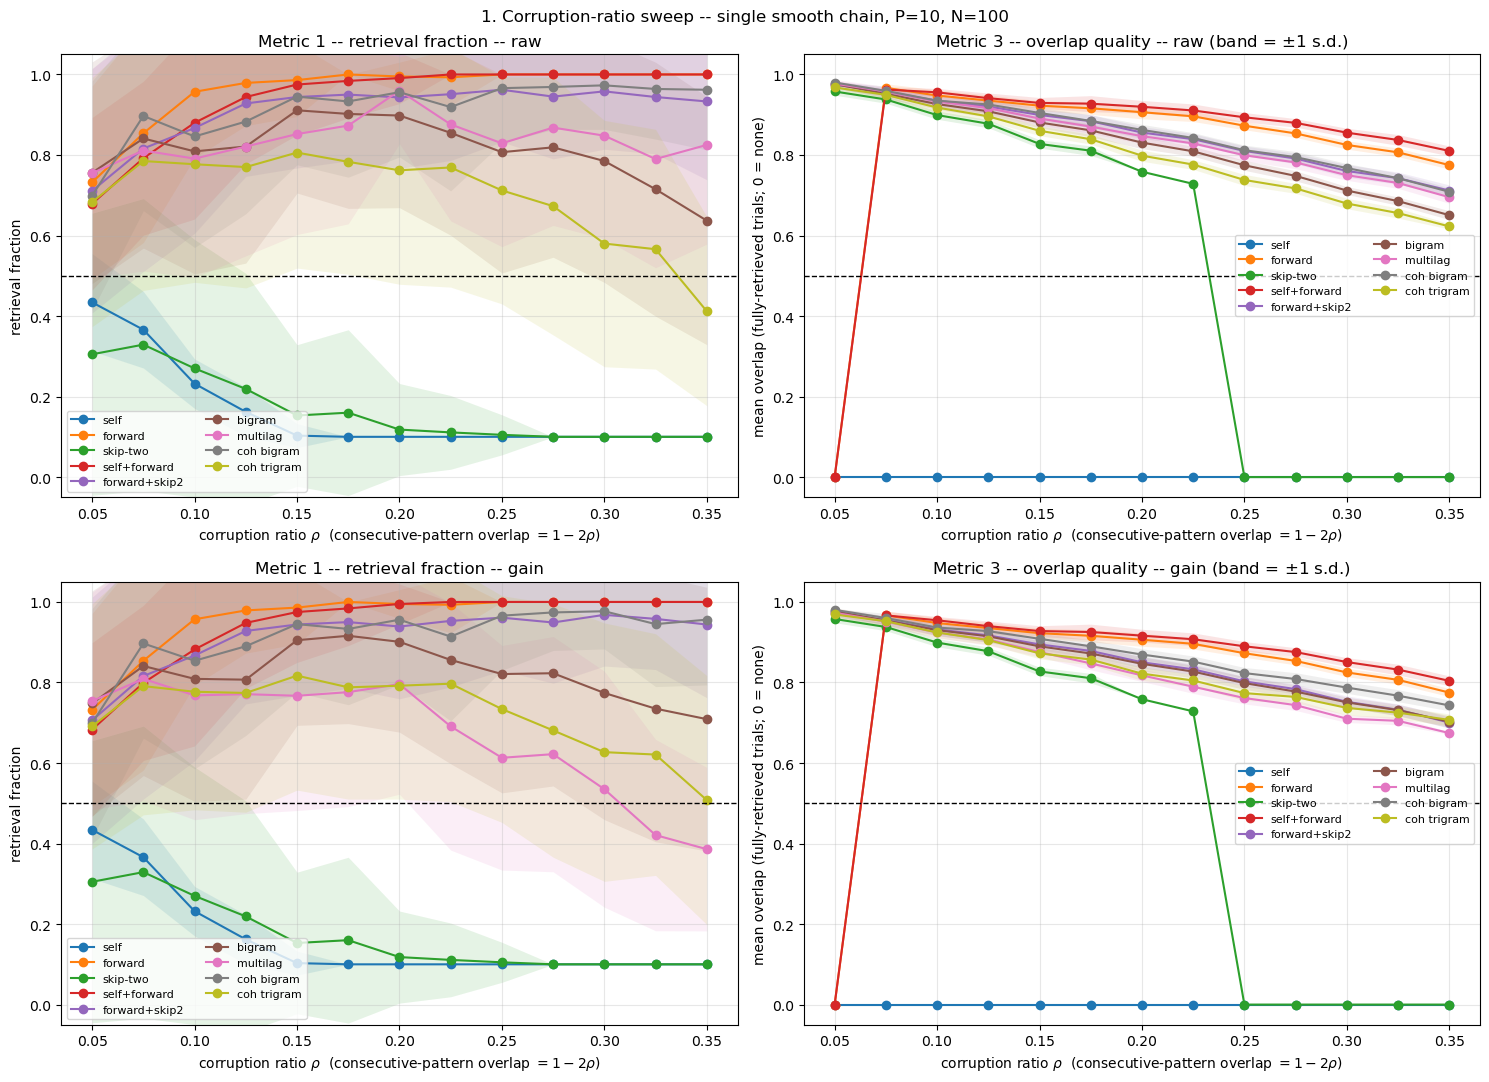

-- raw --
rule             largest rho with fraction >= 90%    fraction at rho=0.20   strict rate at rho=0.20
self                                        never            10% +/- 0.00                        0%
forward                                     0.350           100% +/- 0.04                       98%
skip-two                                    never            12% +/- 0.11                        1%
self+forward                                0.350            99% +/- 0.06                       98%
forward+skip2                               0.350            94% +/- 0.18                       88%
bigram                                      0.175            90% +/- 0.23                       81%
multilag                                    0.200            96% +/- 0.13                       90%
coh bigram                                  0.350            96% +/- 0.16                       92%
coh trigram                                 never            76% +/- 0.28                 

In [12]:
CORRUPTION_SWEEP_RATES = np.linspace(0.05, 0.35, 13)

corruption_results = {}
for tag in ("raw", "gain"):
    corruption_results[tag] = {}
    for rho in CORRUPTION_SWEEP_RATES:
        # the gain correction depends on rho, so rebuild the catalogue at each operating point
        catalogue = (RAW_CATALOGUE if tag == "raw" else
                     {name: kc.proportional_gain(rule, rho) for name, rule in RAW_CATALOGUE.items()})
        corruption_results[tag][rho] = single_sequence_score_sweep(
            catalogue, seq_len=SEQ_LEN, corruption_rate=rho, N=N, trials=SINGLE_SEQ_TRIALS)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for row, tag in enumerate(("raw", "gain")):
    for name in RAW_CATALOGUE:
        band(axes[row, 0], CORRUPTION_SWEEP_RATES,
             [corruption_results[tag][r][name]["retrieval_fraction"] for r in CORRUPTION_SWEEP_RATES],
             [corruption_results[tag][r][name]["fraction_std"] for r in CORRUPTION_SWEEP_RATES],
             label=name)
        band(axes[row, 1], CORRUPTION_SWEEP_RATES,
             [corruption_results[tag][r][name]["mean_overlap"] for r in CORRUPTION_SWEEP_RATES],
             [corruption_results[tag][r][name]["overlap_std"] for r in CORRUPTION_SWEEP_RATES],
             label=name)
    axes[row, 0].axhline(0.5, color="k", ls="--", lw=1)
    axes[row, 0].set_ylabel("retrieval fraction")
    axes[row, 0].set_title(f"Metric 1 -- retrieval fraction -- {tag}")
    axes[row, 1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
    axes[row, 1].set_ylabel("mean overlap (fully-retrieved trials; 0 = none)")
    axes[row, 1].set_title(f"Metric 3 -- overlap quality -- {tag} (band = $\\pm 1$ s.d.)")
    for ax in axes[row]:
        ax.set_xlabel(r"corruption ratio $\rho$  (consecutive-pattern overlap $= 1 - 2\rho$)")
        ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.suptitle(f"1. Corruption-ratio sweep -- single smooth chain, P={SEQ_LEN + 1}, N={N}")
plt.tight_layout(); plt.show()

for tag in ("raw", "gain"):
    print(f"-- {tag} --")
    print(f"{'rule':<15}{'largest rho with fraction >= 90%':>34}{'fraction at rho=0.20':>24}"
          f"{'strict rate at rho=0.20':>26}")
    for name in RAW_CATALOGUE:
        passing = [r for r in CORRUPTION_SWEEP_RATES
                   if corruption_results[tag][r][name]["retrieval_fraction"] >= 0.9]
        best = f"{max(passing):.3f}" if passing else "never"
        near = min(CORRUPTION_SWEEP_RATES, key=lambda r: abs(r - 0.20))
        at = corruption_results[tag][near][name]
        frac = f"{at['retrieval_fraction']:.0%} +/- {at['fraction_std']:.2f}"
        print(f"{name:<15}{best:>34}{frac:>24}{at['retrieval_rate']:>26.0%}")
    print()

# 2. Network-size sweep ($\omega \equiv 0.05$)

Single smooth chain, `SEQ_LEN = 9`. Metrics 1 and 3, **both** catalogues.

`corruption_rate` is held fixed across every `N`, so the absolute Hamming distance between
consecutive patterns grows as `corruption_rate * N`. This asks whether a bigger network makes
the same *relative* task easier, not whether it tolerates the same absolute perturbation.

> **Measured under the old $\sigma_\omega = 0.3$ disorder regime -- not yet re-run at
> $\omega \equiv 0.05$.** Numbers below are pending until these cells are re-executed.

**It does not: the raw context rules get worse.** `bigram` scores 80% at $N=50$, 65% at
$N=100$, 0% from $N=200$ on; `coh bigram` and `coh trigram` do the same. Ruled out by
measurement: *not chain-to-chain variance* (the
per-chain distribution is unimodal and shifts as a whole -- 0.57-0.72 at $N=50$, 0.32-0.56 at
$N=800$); *not noise-assisted escape* (phase noise at $N=400$ makes it worse, 0.58 → 0.25 as
`phase_noise` goes 0 → 0.4); *not a peak artefact* (traces smooth, temporal s.d. ~0.01); *not
`tolerance`* (at 0.3, $N=200$ still scores 10%).

What changes is the **per-step transfer**. Mean peak overlap by position, raw `bigram`:

| $N$ | position 1 → 9 | |
|---|---|---|
| 50 | 0.80 0.73 0.69 0.69 0.66 ... 0.64 0.64 0.70 | plateaus at ≈0.65 |
| 100 | 0.78 0.72 0.68 0.68 0.65 ... 0.55 0.54 0.62 | plateaus at ≈0.55 |
| 200 | 0.76 0.68 0.65 0.62 0.59 ... 0.27 0.22 0.20 | decays geometrically |
| 400 | 0.76 0.70 0.65 0.62 0.59 ... 0.30 0.24 0.17 | decays geometrically |

Below $N \approx 150$ the cascade has a stable non-zero fixed point and self-sustains; above it
that fixed point is gone and the overlap decays toward noise.

**This was specific to `frequency_std = 0.3`** -- under the old regime §2c found the
$N$-dependence disappearing at $\sigma_\omega \le 0.2$, with a critical *disorder* between 0.2
and 0.3 and $N$ not the control parameter. **That mechanism has no counterpart here**: there is
no disorder left to be critical. Whether any $N$-dependence survives at constant
$\omega \equiv 0.05$ is what the re-run of §2 and §2c has to answer -- the single-sequence
evidence so far has constant $\omega$ uniformly *easier* than matched-magnitude disorder, so
the collapse may simply be gone. `proportional_gain`
multiplies the gate by $(1-2\rho)^{-2} = 2.78$, which sustains at every $N$: plateau ≈0.74, flat
in position, **100% from $N = 100$ on**. So the raw curves mean "under-driven at this length",
not "cannot store 10 patterns" -- the opposite of the crossover geometries in
`hetero_rules_run.ipynb`, where over-amplifying an already-sufficient drive destabilizes.

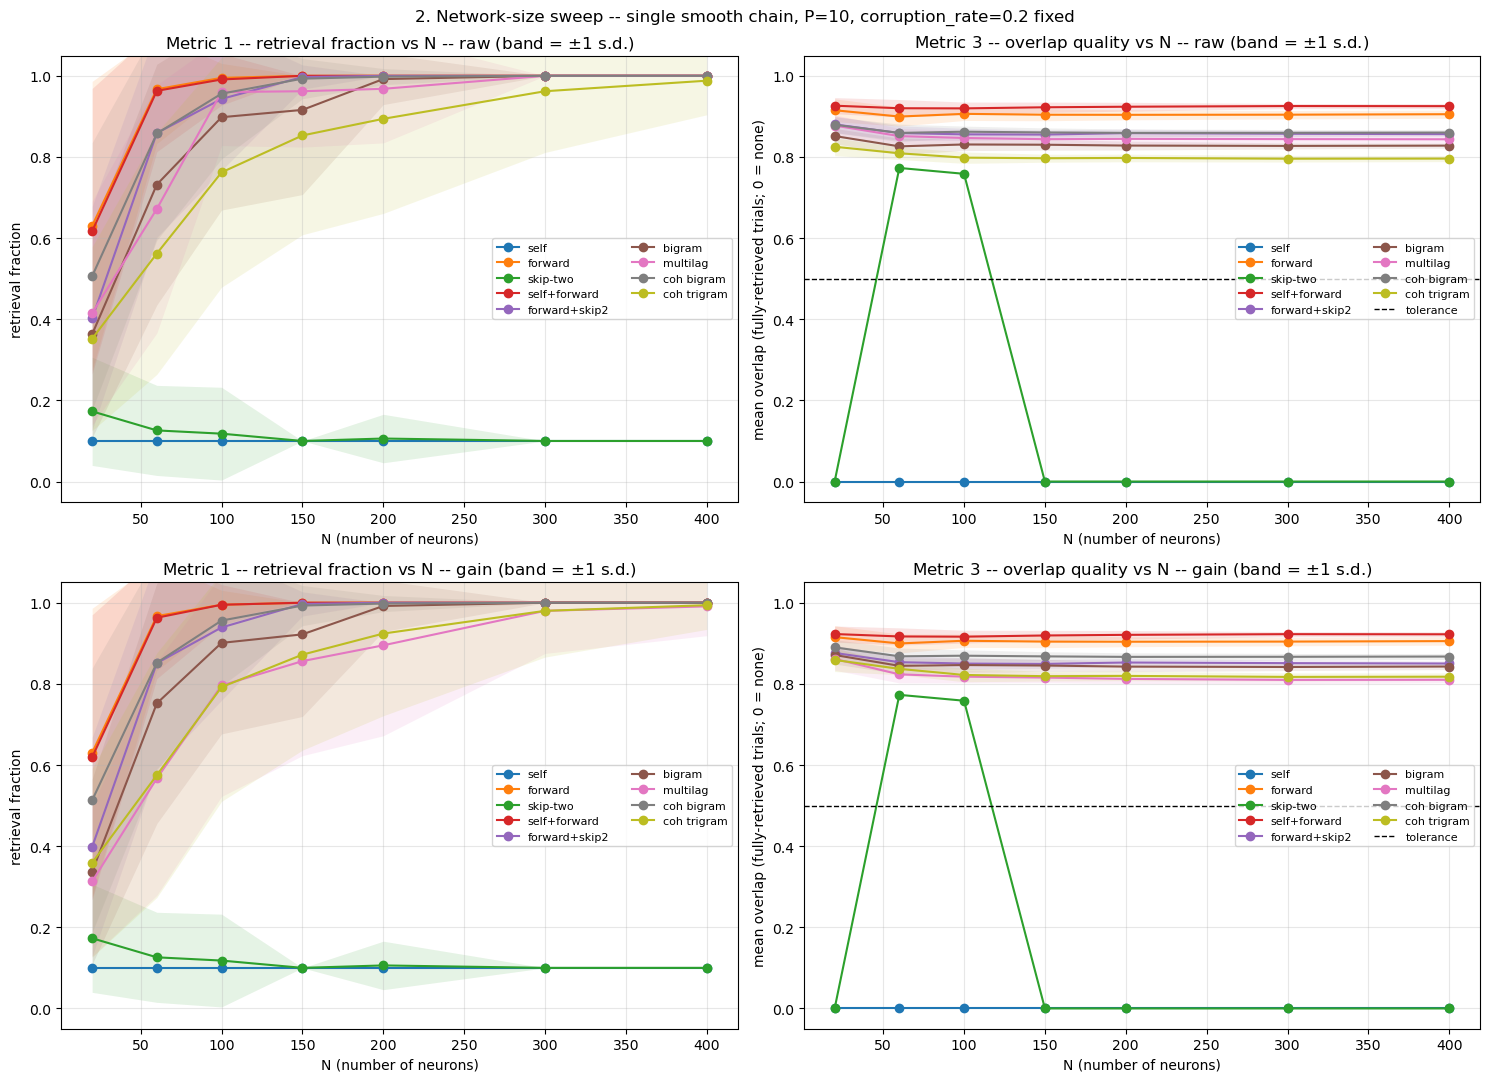

-- raw, metric 1: retrieval fraction (+/- 1 s.d. over trials) --
rule           N=20            N=60            N=100           N=150           N=200           N=300           N=400           
self           10% +/-0.00    10% +/-0.00    10% +/-0.00    10% +/-0.00    10% +/-0.00    10% +/-0.00    10% +/-0.00    
forward        63% +/-0.36    97% +/-0.13    100% +/-0.04   100% +/-0.00   100% +/-0.00   100% +/-0.00   100% +/-0.00   
skip-two       17% +/-0.13    13% +/-0.11    12% +/-0.11    10% +/-0.00    11% +/-0.06    10% +/-0.00    10% +/-0.00    
self+forward   62% +/-0.35    96% +/-0.15    99% +/-0.06    100% +/-0.00   100% +/-0.00   100% +/-0.00   100% +/-0.00   
forward+skip2  40% +/-0.28    86% +/-0.26    94% +/-0.18    100% +/-0.03   100% +/-0.00   100% +/-0.00   100% +/-0.00   
bigram         36% +/-0.25    73% +/-0.30    90% +/-0.23    92% +/-0.21    99% +/-0.06    100% +/-0.00   100% +/-0.00   
multilag       41% +/-0.28    67% +/-0.31    96% +/-0.13    96% +/-0.14    97% +/

In [13]:
N_SWEEP = [20, 60, 100, 150, 200, 300, 400]

n_sweep_results = {
    tag: {n: single_sequence_score_sweep(catalogue, seq_len=SEQ_LEN,
                                         corruption_rate=CONFIG["corruption_rate"],
                                         N=n, trials=SINGLE_SEQ_TRIALS)
          for n in N_SWEEP}
    for tag, catalogue in (("raw", RAW_CATALOGUE), ("gain", GAIN_CATALOGUE))
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for row, tag in enumerate(("raw", "gain")):
    res = n_sweep_results[tag]
    for name in RAW_CATALOGUE:
        band(axes[row, 0], N_SWEEP, [res[n][name]["retrieval_fraction"] for n in N_SWEEP],
             [res[n][name]["fraction_std"] for n in N_SWEEP], label=name)
        band(axes[row, 1], N_SWEEP, [res[n][name]["mean_overlap"] for n in N_SWEEP],
             [res[n][name]["overlap_std"] for n in N_SWEEP], label=name)
    axes[row, 0].set_ylabel("retrieval fraction")
    axes[row, 0].set_title(f"Metric 1 -- retrieval fraction vs N -- {tag} (band = $\\pm 1$ s.d.)")
    axes[row, 1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
    axes[row, 1].set_ylabel("mean overlap (fully-retrieved trials; 0 = none)")
    axes[row, 1].set_title(f"Metric 3 -- overlap quality vs N -- {tag} (band = $\\pm 1$ s.d.)")
    for ax in axes[row]:
        ax.set_xlabel("N (number of neurons)")
        ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.suptitle(f"2. Network-size sweep -- single smooth chain, P={SEQ_LEN + 1}, "
             f"corruption_rate={CONFIG['corruption_rate']} fixed")
plt.tight_layout(); plt.show()

for tag in ("raw", "gain"):
    for key, sd_key, label in (
            ("retrieval_fraction", "fraction_std", "metric 1: retrieval fraction (+/- 1 s.d. over trials)"),
            ("retrieval_rate", None, "metric 2: strict full-retrieval rate")):
        print(f"-- {tag}, {label} --")
        width = 15 if sd_key else 8
        print(f"{'rule':<15}" + "".join(f"N={n:<{width - 1}}" for n in N_SWEEP))
        for name in RAW_CATALOGUE:
            cells = []
            for n in N_SWEEP:
                r = n_sweep_results[tag][n][name]
                cells.append(f"{r[key]:.0%} +/-{r[sd_key]:.2f}" if sd_key else f"{r[key]:.0%}")
            print(f"{name:<15}" + "".join(cell.ljust(width) for cell in cells))
        print()


## 2b. $L$-fraction against $N$, in the style of `kuramoto_sequence.ipynb` ($\omega \equiv 0.05$)

Metric 1 is all-or-nothing. `kuramoto/sequence/kuramoto_sequence.ipynb` measures the same axis
with a partial-credit quantity instead --

$$\text{retrieval fraction} = \frac{\texttt{compare\_to\_stored\_sequence(retrieved, seq)}}{P}$$

the fraction of the chain recovered *in order* before the first mismatch -- sweeping $N$ with
the spread across generation seeds as error bars. That notebook uses it to find $L_{\max}(N)$
at a `retrieval_tolerance` of 0.9; here the length is fixed at `SEQ_LEN = 9` and $N$ is the
swept axis, so this is a vertical slice through that curve.

Left: mean retrieval fraction over `SEQ_SWEEP_SEEDS` seeds, $\pm 1$ s.d. Right: the fraction
of seeds clearing `RETRIEVAL_TOLERANCE`. This is the panel that shows the raw rules degrading
*gradually* with $N$ (0.93, 0.90, 0.53, 0.57 for `bigram`) rather than falling off a cliff --
which is what identifies weakening drive rather than an abrupt capacity limit.


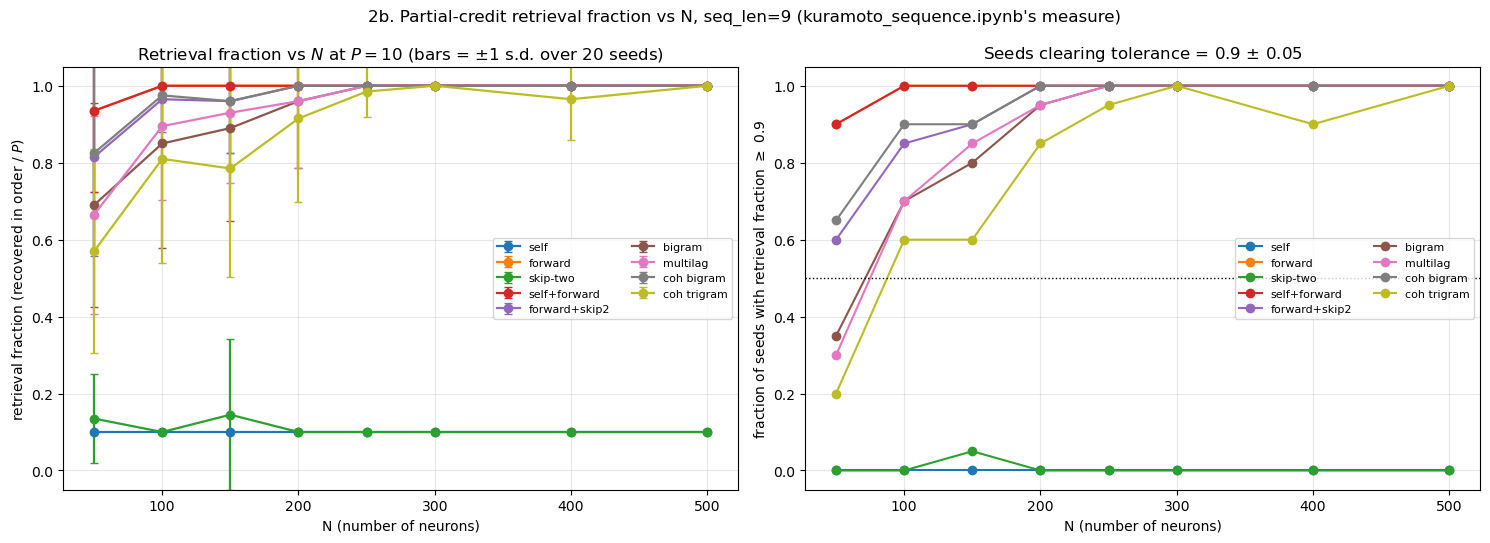

mean retrieval fraction at P=10, 20 seeds
rule           N=50     N=100    N=150    N=200    N=250    N=300    N=400    N=500    
self           0.10     0.10     0.10     0.10     0.10     0.10     0.10     0.10     
forward        0.94     1.00     1.00     1.00     1.00     1.00     1.00     1.00     
skip-two       0.14     0.10     0.15     0.10     0.10     0.10     0.10     0.10     
self+forward   0.94     1.00     1.00     1.00     1.00     1.00     1.00     1.00     
forward+skip2  0.82     0.97     0.96     1.00     1.00     1.00     1.00     1.00     
bigram         0.69     0.85     0.89     0.96     1.00     1.00     1.00     1.00     
multilag       0.67     0.89     0.93     0.96     1.00     1.00     1.00     1.00     
coh bigram     0.82     0.97     0.96     1.00     1.00     1.00     1.00     1.00     
coh trigram    0.57     0.81     0.78     0.92     0.98     1.00     0.97     1.00     


In [14]:
SEQ_N_SWEEP = [50, 100, 150, 200, 250, 300, 400, 500]
SEQ_SWEEP_SEEDS = 20                       # kuramoto_sequence.ipynb's seed_range
RETRIEVAL_TOLERANCE = 0.9                  # its SWEEP_CONFIG["retrieval_tolerance"]
RETRIEVAL_TOLERANCE_MARGIN = 0.05          # its SWEEP_CONFIG["retrieval_tolerance_margin"]


def retrieval_fraction(net, seq, duration):
    """The partial-credit measure of kuramoto_sequence.ipynb: the fraction of the stored
    sequence recovered, in order, before the first mismatch. 1.0 is full retrieval (and is
    exactly metric 1 succeeding); 0.4 means the chain broke 40% of the way in."""
    result = net.simulate(seq, T=duration)
    retrieved = net.decode_sequence_online(result, seq, margin=MARGIN)
    return net.compare_to_stored_sequence(retrieved, seq) / len(seq)


def fraction_vs_N(catalogue, seq_len, N_values, seeds=SEQ_SWEEP_SEEDS, duration=None):
    """For each rule and each N, the retrieval fraction over `seeds` generation seeds.
    Every rule sees the same seeds at every N, so the curves are directly comparable."""
    duration = DWELL_PER_TRANSITION * seq_len if duration is None else duration
    out = {}
    for name, rule in catalogue.items():
        per_N = []
        for n in N_values:
            net = kc.ContextNetwork(rule=rule, N=n, seed=10, **CONFIG)
            fracs = [retrieval_fraction(net,
                                        krm.generate_sequence(n, seq_len, CONFIG["corruption_rate"],
                                                              name="A", seed=s),
                                        duration)
                     for s in range(seeds)]
            per_N.append(np.asarray(fracs))
        out[name] = per_N
    return out


frac_results = fraction_vs_N(RAW_CATALOGUE, SEQ_LEN, SEQ_N_SWEEP)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for name, per_N in frac_results.items():
    means = [f.mean() for f in per_N]
    stds = [f.std() for f in per_N]
    axes[0].errorbar(SEQ_N_SWEEP, means, yerr=stds, marker="o", capsize=3, lw=1.6, label=name)
    axes[1].plot(SEQ_N_SWEEP, [(f >= RETRIEVAL_TOLERANCE).mean() for f in per_N], "-o", label=name)

axes[0].set_ylabel("retrieval fraction (recovered in order / $P$)")
axes[0].set_title(f"Retrieval fraction vs $N$ at $P={SEQ_LEN + 1}$ (bars = $\\pm 1$ s.d. over {SEQ_SWEEP_SEEDS} seeds)")
axes[1].axhline(0.5, color="k", ls=":", lw=1)
axes[1].set_ylabel(f"fraction of seeds with retrieval fraction $\\geq$ {RETRIEVAL_TOLERANCE}")
axes[1].set_title(f"Seeds clearing tolerance = {RETRIEVAL_TOLERANCE} "
                  f"$\\pm$ {RETRIEVAL_TOLERANCE_MARGIN}")
for ax in axes:
    ax.set_xlabel("N (number of neurons)")
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.suptitle(f"2b. Partial-credit retrieval fraction vs N, seq_len={SEQ_LEN} "
             f"(kuramoto_sequence.ipynb's measure)")
plt.tight_layout(); plt.show()

print(f"mean retrieval fraction at P={SEQ_LEN + 1}, {SEQ_SWEEP_SEEDS} seeds")
print(f"{'rule':<15}" + "".join(f"N={n:<7}" for n in SEQ_N_SWEEP))
for name, per_N in frac_results.items():
    print(f"{name:<15}" + "".join(f"{f.mean():<9.2f}" for f in per_N))


---

## 2c. Scaling $\omega$ with $N$  ($\omega$ **swept**, 0.01 - 0.45)

§2 leaves a question: do the raw context rules fail at large $N$, and is that about $N$ or
about $\omega$? The overlaps concentrate as $1/\sqrt{N}$ while the constant $\omega$ stays put,
so the natural thing to try is scaling $\omega$ down with $N$ to match:

$$\omega(N) = \omega_0 \left(\frac{N_0}{N}\right)^{p}, \qquad p \in \{0, \tfrac{1}{2}, 1\}$$

with $\omega_0 = 0.05$ at $N_0 = 100$. $p = 0$ is §2's fixed-$\omega$ sweep. Mind the floor from
`hetero_rules_run.ipynb` §8: below $\omega \approx 0.01$ the escape outlasts the duration, so at
large $N$ an aggressive $p$ leaves the usable band from *below*.

The grid below is the control that makes the answer unambiguous: it varies $N$ and $\omega$
**independently**, so a scaling law shows up as a tilted contour and a pure $\omega$ effect
shows up as flat columns.


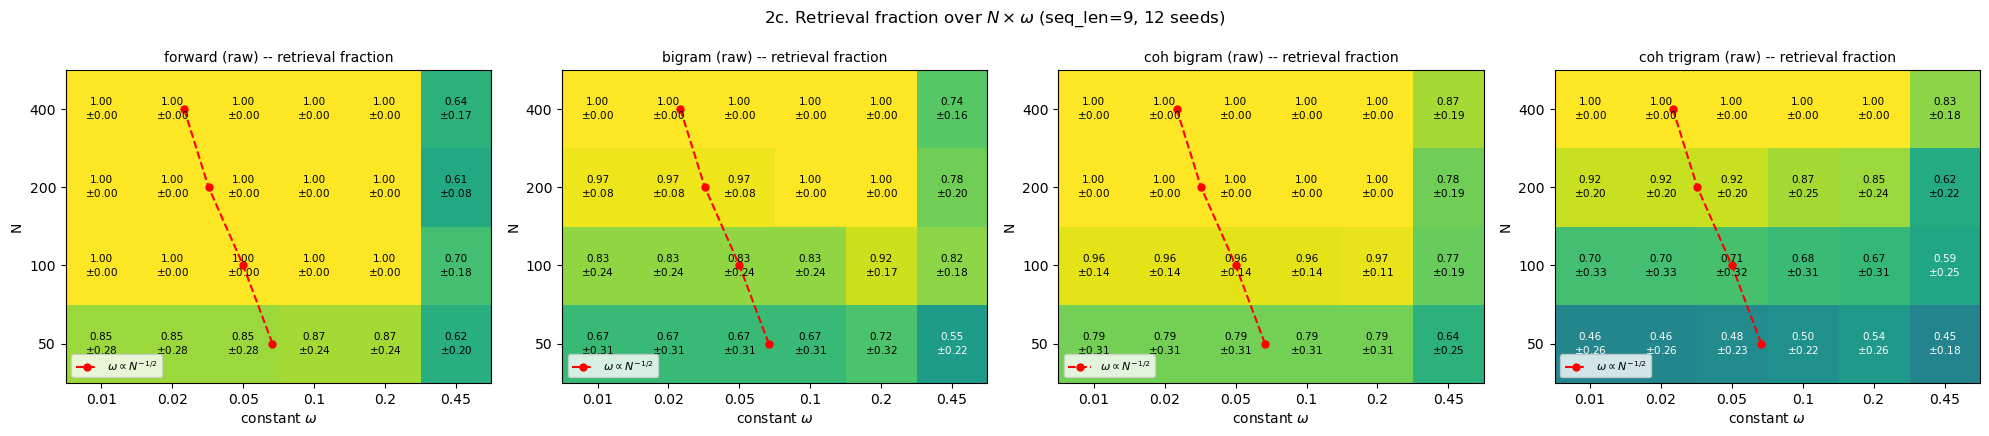

Metric 1 along the scaling laws, omega(N) = 0.05 * (100/N)^p
-- p = 0   (omega: N=50:0.050, N=100:0.050, N=200:0.050, N=400:0.050)
   rule         N=50          N=100         N=200         N=400         
   forward      0.85+/-0.28 1.00+/-0.00 1.00+/-0.00 1.00+/-0.00 
   bigram       0.67+/-0.31 0.83+/-0.24 0.97+/-0.08 1.00+/-0.00 
   coh bigram   0.79+/-0.31 0.96+/-0.14 1.00+/-0.00 1.00+/-0.00 
   coh trigram  0.48+/-0.23 0.71+/-0.32 0.92+/-0.20 1.00+/-0.00 

-- p = 0.5   (omega: N=50:0.071, N=100:0.050, N=200:0.035, N=400:0.025)
   rule         N=50          N=100         N=200         N=400         
   forward      0.87+/-0.24 1.00+/-0.00 1.00+/-0.00 1.00+/-0.00 
   bigram       0.67+/-0.31 0.83+/-0.24 0.97+/-0.08 1.00+/-0.00 
   coh bigram   0.79+/-0.31 0.96+/-0.14 1.00+/-0.00 1.00+/-0.00 
   coh trigram  0.50+/-0.22 0.71+/-0.32 0.92+/-0.20 1.00+/-0.00 

-- p = 1   (omega: N=50:0.100, N=100:0.050, N=200:0.025, N=400:0.013)
   rule         N=50          N=100         N=200         N

In [15]:
OMEGA_SCALE_N = [50, 100, 200, 400]
OMEGA_SCALE_W = [0.01, 0.02, 0.05, 0.1, 0.2, 0.45]   # constant omega, frequency_std = 0
OMEGA_SCALE_RULES = ["forward", "bigram", "coh bigram", "coh trigram"]
W_REF, N_REF = OMEGA, 100            # the configured operating point
OMEGA_SCALE_TRIALS = 12


def fraction_at(rule_name, n, w, trials=OMEGA_SCALE_TRIALS):
    """Metric 1 for one rule at one (N, constant omega), frequency_std = 0.
    Returns (mean, s.d.) over trials -- the spread matters here, because a cell sitting at
    the edge of the band is a mix of full and failed chains, not a uniformly partial one."""
    res = single_sequence_score_sweep(
        {rule_name: RAW_CATALOGUE[rule_name]}, seq_len=SEQ_LEN,
        corruption_rate=CONFIG["corruption_rate"], N=n, trials=trials,
        config_overrides={"frequency_mean": w, "frequency_std": 0.0})
    return res[rule_name]["retrieval_fraction"], res[rule_name]["fraction_std"]


_omega_cells = {name: [[fraction_at(name, n, w_) for w_ in OMEGA_SCALE_W]
                       for n in OMEGA_SCALE_N]
                for name in OMEGA_SCALE_RULES}
omega_grid = {name: np.array([[m for m, _ in row] for row in cells])
              for name, cells in _omega_cells.items()}
omega_grid_sd = {name: np.array([[sd for _, sd in row] for row in cells])
                 for name, cells in _omega_cells.items()}

fig, axes = plt.subplots(1, len(OMEGA_SCALE_RULES), figsize=(5.0 * len(OMEGA_SCALE_RULES), 4.4))
for ax, name in zip(np.atleast_1d(axes), OMEGA_SCALE_RULES):
    grid, grid_sd = omega_grid[name], omega_grid_sd[name]
    im = ax.imshow(grid, cmap="viridis", vmin=0.0, vmax=1.0, origin="lower", aspect="auto")
    for i in range(len(OMEGA_SCALE_N)):
        for j in range(len(OMEGA_SCALE_W)):
            ax.text(j, i, f"{grid[i, j]:.2f}\n$\\pm${grid_sd[i, j]:.2f}", ha="center",
                    va="center", fontsize=7.5,
                    color="w" if grid[i, j] < 0.6 else "k")
    # the p = 1/2 scaling law, drawn on the grid for comparison
    xs = [np.interp(W_REF * (N_REF / n) ** 0.5, OMEGA_SCALE_W,
                    range(len(OMEGA_SCALE_W))) for n in OMEGA_SCALE_N]
    ax.plot(xs, range(len(OMEGA_SCALE_N)), "r--o", lw=1.5, ms=5,
            label=r"$\omega \propto N^{-1/2}$")
    ax.set_xticks(range(len(OMEGA_SCALE_W)), [f"{s:g}" for s in OMEGA_SCALE_W])
    ax.set_yticks(range(len(OMEGA_SCALE_N)), [str(n) for n in OMEGA_SCALE_N])
    ax.set_xlabel(r"constant $\omega$"); ax.set_ylabel("N")
    ax.set_title(f"{name} (raw) -- retrieval fraction", fontsize=10)
    ax.legend(fontsize=8, loc="lower left")
fig.suptitle(f"2c. Retrieval fraction over $N \\times \\omega$ (seq_len={SEQ_LEN}, "
             f"{OMEGA_SCALE_TRIALS} seeds)")
plt.tight_layout(); plt.show()

print(f"Metric 1 along the scaling laws, omega(N) = {W_REF} * ({N_REF}/N)^p")
for p_exp in (0.0, 0.5, 1.0):
    print(f"-- p = {p_exp:g}   (omega: " +
          ", ".join(f"N={n}:{W_REF * (N_REF / n) ** p_exp:.3f}" for n in OMEGA_SCALE_N) + ")")
    print(f"   {'rule':<13}" + "".join(f"N={n:<12}" for n in OMEGA_SCALE_N))
    for name in OMEGA_SCALE_RULES:
        row = "".join("{:.2f}+/-{:<5.2f}".format(*fraction_at(name, n, W_REF * (N_REF / n) ** p_exp))
                      for n in OMEGA_SCALE_N)
        print(f"   {name:<13}{row}")
    print()


### What the grid says

> **Measured under the old $\sigma_\omega = 0.3$ disorder regime -- not yet re-run at
> $\omega \equiv 0.05$.** Kept for the record. The structural question it answers -- scaling
> law versus flat columns -- carries over unchanged to the $\omega$ grid; its numbers do not,
> and the mechanism below (a *critical disorder*) has no counterpart once the disorder is gone.

Scaling $\sigma_\omega$ down with $N$ **does** restore the raw context rules -- at
$p = \tfrac{1}{2}$, `bigram` and `coh bigram` reach 1.00 at $N = 200$ and $400$ and
`coh trigram` 0.94 / 1.00, against 0.55 / 0.58 at fixed $\sigma_\omega$. The grid shows that is
**not** a scaling law doing the work.

Read the columns: at $\sigma_\omega \le 0.2$ every rule scores 1.00 at every $N \ge 100$, no
$N$-dependence at all. It appears only in the $\sigma_\omega = 0.3$ column -- the configured
value -- running 0.89, 0.88, 0.55, 0.56 for `bigram`. At $0.45$ everything fails everywhere.

So there is a **critical disorder** between 0.2 and 0.3, and the default $\sigma_\omega = 0.3$
sits on that edge: inside at small $N$, outside at large $N$. §2's collapse with $N$ is that
edge moving down as the overlaps concentrate, not a capacity limit. The $p = \tfrac{1}{2}$ curve
works because it crosses into the $\sigma \le 0.2$ region, not because it matches any
$1/\sqrt{N}$ in the dynamics.

$N = 50$ is the one row that never reaches 1.00 (0.84-0.95): 10 patterns in 50 neurons is a
genuinely loaded network, which is the capacity effect the rest of the grid is *not*.

---

# 3. Superposition of learning rules ($\omega \equiv 0.05$)

**Topology:** single smooth chain, `SEQ_LEN = 9`. **Metrics:** 1, strict full-retrieval rate;
2, overlap quality conditional on it, with its spread.

All `C(4,2) = 6` pairs among the four context rules (`bigram`, `coh bigram`, `coh trigram`,
`multilag`), mixed via `kc.mixture` at relative weight `w` (`w=0` is the pure first rule, `w=1`
the pure second). `multilag_rule` has no single `weight=` kwarg -- its weight lives across three
rows -- so the mixing coefficient is applied to a rule's *whole* weight column after
construction (`scaled`, below), treating all four base rules the same regardless of how many
rows they expand to.

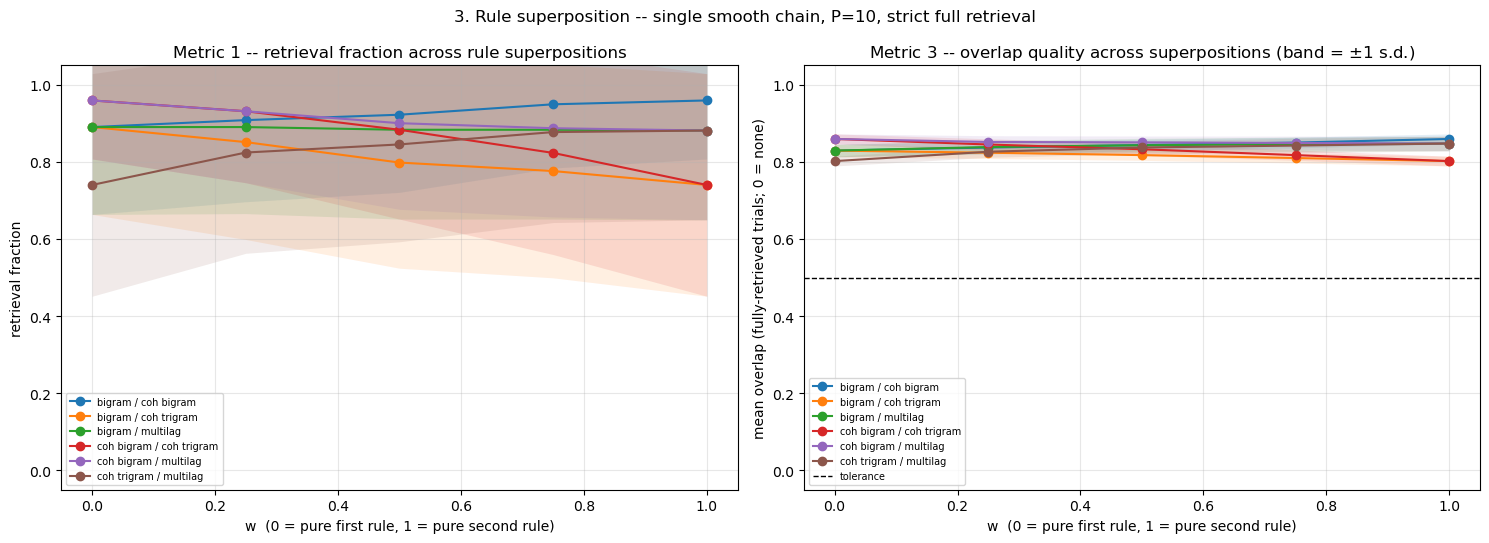

pair                        w=0               w=0.25            w=0.5             w=0.75            w=1                  (retrieval fraction +/- 1 s.d. / strict rate)
bigram / coh bigram         89%+/-0.23/79%  91%+/-0.21/83%  92%+/-0.20/86%  95%+/-0.17/91%  96%+/-0.15/93%  
bigram / coh trigram        89%+/-0.23/79%  85%+/-0.25/71%  80%+/-0.27/60%  78%+/-0.28/54%  74%+/-0.29/48%  
bigram / multilag           89%+/-0.23/79%  89%+/-0.22/79%  88%+/-0.23/78%  88%+/-0.23/78%  88%+/-0.23/77%  
coh bigram / coh trigram    96%+/-0.15/93%  93%+/-0.19/87%  88%+/-0.23/78%  82%+/-0.26/64%  74%+/-0.29/48%  
coh bigram / multilag       96%+/-0.15/93%  93%+/-0.19/87%  90%+/-0.22/82%  89%+/-0.23/79%  88%+/-0.23/77%  
coh trigram / multilag      74%+/-0.29/48%  82%+/-0.26/64%  84%+/-0.25/69%  88%+/-0.23/76%  88%+/-0.23/77%  


In [16]:
BASE_RULES = {
    "bigram":      kc.bigram_rule(),
    "coh bigram":  kc.coherent_bigram_rule(),
    "coh trigram": kc.coherent_trigram_rule(),
    "multilag":    kc.multilag_rule((1.0, 1.0, 1.0)),
}


def scaled(rule, w):
    """Copy of `rule` with its whole weight column multiplied by w -- works uniformly for
    single-row and multi-row rules, unlike passing weight= to the original builder."""
    rule = np.atleast_2d(np.asarray(rule, dtype=np.float64)).copy()
    rule[:, -1] *= w
    return rule


SUPERPOSITION_WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0]

superposition_results = {}
for name_a, name_b in itertools.combinations(BASE_RULES, 2):
    pair_label = f"{name_a} / {name_b}"
    per_weight = []
    for w in SUPERPOSITION_WEIGHTS:
        rule = kc.mixture(scaled(BASE_RULES[name_a], 1 - w), scaled(BASE_RULES[name_b], w))
        result = single_sequence_score_sweep({pair_label: rule}, seq_len=SEQ_LEN,
                                             corruption_rate=CONFIG["corruption_rate"],
                                             N=N, trials=SINGLE_SEQ_TRIALS)
        per_weight.append(result[pair_label])
    superposition_results[pair_label] = per_weight

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for pair_label, per_weight in superposition_results.items():
    band(axes[0], SUPERPOSITION_WEIGHTS, [r["retrieval_fraction"] for r in per_weight],
         [r["fraction_std"] for r in per_weight], label=pair_label)
    band(axes[1], SUPERPOSITION_WEIGHTS, [r["mean_overlap"] for r in per_weight],
         [r["overlap_std"] for r in per_weight], label=pair_label)
axes[0].set_xlabel("w  (0 = pure first rule, 1 = pure second rule)")
axes[0].set_ylabel("retrieval fraction")
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title("Metric 1 -- retrieval fraction across rule superpositions")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_xlabel("w  (0 = pure first rule, 1 = pure second rule)")
axes[1].set_ylabel("mean overlap (fully-retrieved trials; 0 = none)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Metric 3 -- overlap quality across superpositions (band = $\\pm 1$ s.d.)")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
fig.suptitle(f"3. Rule superposition -- single smooth chain, P={SEQ_LEN + 1}, strict full retrieval")
plt.tight_layout(); plt.show()

print(f"{'pair':<28}" + "".join(f"w={w:<16g}" for w in SUPERPOSITION_WEIGHTS)
      + "   (retrieval fraction +/- 1 s.d. / strict rate)")
for pair_label, per_weight in superposition_results.items():
    print(f"{pair_label:<28}"
          + "".join(f"{r['retrieval_fraction']:.0%}+/-{r['fraction_std']:.2f}/{r['retrieval_rate']:<5.0%}"
                    for r in per_weight))


---

# 4. Crossover geometries ($\omega \equiv 0.05$)

Every sweep above scored a single, non-branching sequence. The same correctness-first mean
overlap methodology extends to the two-sequence crossover experiments of
`hetero_rules_run.ipynb`: a cueing attempt contributes to `mean_overlap` only when
`classify_unshared` calls it `"correct"` (every *unshared* pattern of the cued branch decoded,
in order); a failed attempt only lowers `retrieval_rate`. Shared positions are excluded, since
both branches store the identical pattern there.

Four before-shared-after geometries, the same set as `hetero_rules_run.ipynb`:

| tag | spec | $P$ | shared | $L$ | duration | reach needed |
|---|---|---|---|---|---|---|
| `2-1-2` | **(a)** eq (7) | 5 | $\{2\}$ | 1 | 100 | 1 -- `bigram`, `coh bigram` |
| `2-2-2` | **(c)** eq (9) | 6 | $\{2,3\}$ | 2 | 120 | 2 -- only `coh trigram` |
| `2-3-2` | failure case | 7 | $\{2,3,4\}$ | 3 | 140 | 3 -- nothing in the catalogue |
| `1-1-1` | legacy | 3 | $\{1\}$ | 1 | 60 | 1 |

Scored, as everywhere else, with the streaming decoder: what matters is which branch the
trajectory commits to and in what order.

-- 2-1-2 --
  self            success=   0%   overlap=n/a (none correct)
  forward         success=  26%   overlap=+0.934 +/- 0.012
  skip-two        success=   2%   overlap=+0.861 +/- 0.011
  self+forward    success=   1%   overlap=+0.946 +/- 0.001
  forward+skip2   success=  42%   overlap=+0.920 +/- 0.013
  bigram          success=  60%   overlap=+0.913 +/- 0.012
  multilag        success=  42%   overlap=+0.925 +/- 0.010
  coh bigram      success=  52%   overlap=+0.925 +/- 0.009
  coh trigram     success=  52%   overlap=+0.903 +/- 0.009
-- 2-2-2 --
  self            success=   0%   overlap=n/a (none correct)
  forward         success=  30%   overlap=+0.934 +/- 0.012
  skip-two        success=   1%   overlap=+0.858 +/- 0.013
  self+forward    success=   3%   overlap=+0.929 +/- 0.016
  forward+skip2   success=  30%   overlap=+0.918 +/- 0.012
  bigram          success=  35%   overlap=+0.908 +/- 0.012
  multilag        success=  32%   overlap=+0.923 +/- 0.012
  coh bigram      success=  

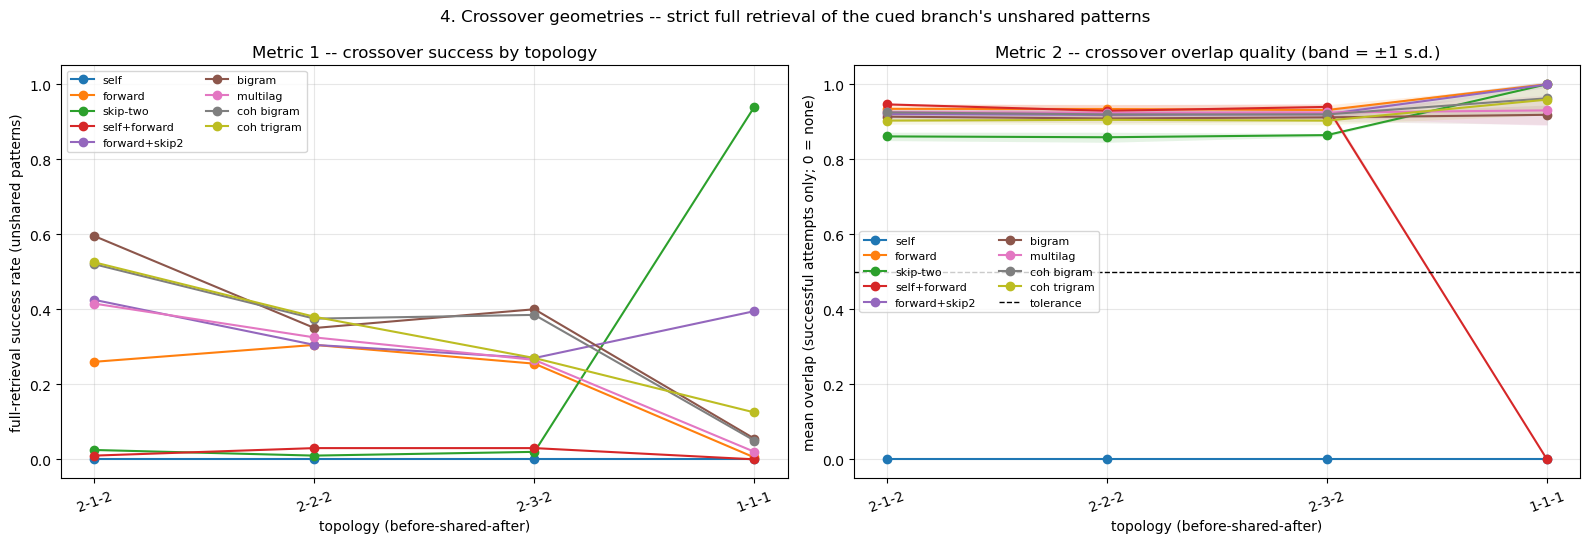

In [17]:
def make_crossover_pair(N, corruption_rate, origin_seed, mutation_seeds,
                        seq_len, shared_idx):
    """The two sequences "A" and "B", `seq_len` patterns each, sharing a contiguous run at
    `shared_idx`. Two branches exactly.
    Ported from hetero_rules_run.ipynb -- see that notebook for the full explanation."""
    shared_idx = sorted(shared_idx)
    lo, hi = shared_idx[0], shared_idx[-1]
    if shared_idx != list(range(lo, hi + 1)):
        raise ValueError("shared_idx must be a contiguous run.")
    if not (0 < lo and hi < seq_len - 1):
        raise ValueError("The run needs at least one unshared pattern on each side.")

    seeds = iter(mutation_seeds)
    mutate = lambda v: krm.corrupt_phase(v, corruption_rate, np.random.default_rng(next(seeds)))

    run = [np.random.default_rng(origin_seed).choice([0.0, np.pi], size=N)]
    for _ in range(hi - lo):
        run.append(mutate(run[-1]))

    multi = krm.MultiSequence()
    for name in ("A", "B"):
        prefix, v = [], run[0]
        for _ in range(lo):
            v = mutate(v); prefix.append(v)
        prefix.reverse()
        suffix, v = [], run[-1]
        for _ in range(seq_len - 1 - hi):
            v = mutate(v); suffix.append(v)
        multi.add(krm.sequence_from_patterns(name, prefix + list(run) + suffix))
    return multi


def classify_unshared(retrieved, multi, name, shared_idx):
    """METRIC 1 -- correct = all unshared positions of the cued branch decoded, in order.
    Ported from hetero_rules_run.ipynb -- see that notebook for the full explanation."""
    other = "B" if name == "A" else "A"
    shared = set(shared_idx)
    pending = iter([k for k in range(len(multi[name])) if k not in shared])
    target = next(pending, None)
    for seq, idx in retrieved:
        if target is None:
            break
        if idx in shared:
            continue
        if seq == other and idx >= target:
            return "crossed"
        if seq == name and idx == target:
            target = next(pending, None)
    return "correct" if target is None else "incomplete"


def crossover_score_sweep(catalogue, seq_len, shared_idx,
                          trials=SINGLE_SEQ_TRIALS, seed=0, duration=100.0, boundary=None):
    """Like single_sequence_score_sweep, but for a branching topology.

    retrieval_rate (metric 1) is the STRICT success rate -- the number of cueing attempts
    (both A and B, each counted separately) classified "correct" by `classify_unshared`,
    divided by the number of attempts.
    mean_overlap / overlap_std (metric 2) average, only over those successful attempts, the
    mean peak overlap of the cued branch's own unshared patterns."""
    rng = np.random.default_rng(seed)
    shared = set(shared_idx)
    results = {}
    for name, rule in catalogue.items():
        net = kc.ContextNetwork(rule=rule, N=N, seed=10, **CONFIG)
        overlap_vals, n_attempts = [], 0
        for _ in range(trials):
            origin_seed = int(rng.integers(SEED_POOL))
            mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
            multi = make_crossover_pair(N, CONFIG["corruption_rate"], origin_seed,
                                        mutation_seeds, seq_len, shared_idx)
            labels = multi.labels()
            for cue_name in ("A", "B"):
                n_attempts += 1
                result = net.simulate(multi, cue=multi[cue_name], cue_idx=0, T=duration, boundary=boundary)
                retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)
                if classify_unshared(retrieved, multi, cue_name, shared_idx) == "correct":
                    overlaps = net.overlaps(result["theta_history"], multi)
                    own_unshared = [labels.index((cue_name, k)) for k in range(seq_len) if k not in shared]
                    overlap_vals.append(float(overlaps[:, own_unshared].max(axis=0).mean()))
        results[name] = dict(
            retrieval_rate=len(overlap_vals) / n_attempts,
            n_correct=len(overlap_vals),
            mean_overlap=float(np.mean(overlap_vals)) if overlap_vals else float("nan"),
            overlap_std=float(np.std(overlap_vals)) if overlap_vals else float("nan"),
            overlap_var=float(np.var(overlap_vals)) if overlap_vals else float("nan"),
        )
    return results


# before-shared-after; all built as smooth (mutation-chain) sequences.
# Same table as hetero_rules_run.ipynb's GEOMETRIES.
CROSSOVER_GEOMETRIES = {
    "2-1-2": dict(seq_len=5, shared_idx=(2,),      duration=100.0),   # (a) eq (7)
    "2-2-2": dict(seq_len=6, shared_idx=(2, 3),    duration=120.0),   # (c) eq (9)
    "2-3-2": dict(seq_len=7, shared_idx=(2, 3, 4), duration=140.0),   # the failure case
    "1-1-1": dict(seq_len=3, shared_idx=(1,),      duration=60.0),    # legacy
}

crossover_results = {tag: crossover_score_sweep(RAW_CATALOGUE, **geom)
                     for tag, geom in CROSSOVER_GEOMETRIES.items()}

for tag in CROSSOVER_GEOMETRIES:
    print(f"-- {tag} --")
    for name, r in crossover_results[tag].items():
        q = (f"{r['mean_overlap']:+.3f} +/- {r['overlap_std']:.3f}"
             if r["mean_overlap"] == r["mean_overlap"] else "n/a (none correct)")
        print(f"  {name:<15} success={r['retrieval_rate']:>5.0%}   overlap={q}")

tags = list(CROSSOVER_GEOMETRIES)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for name in RAW_CATALOGUE:
    axes[0].plot(tags, [crossover_results[t][name]["retrieval_rate"] for t in tags], "-o", label=name)
    band(axes[1], tags, [crossover_results[t][name]["mean_overlap"] for t in tags],
         [crossover_results[t][name]["overlap_std"] for t in tags], label=name)
axes[0].set_ylabel("full-retrieval success rate (unshared patterns)")
axes[0].set_title("Metric 1 -- crossover success by topology")
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_ylabel("mean overlap (successful attempts only; 0 = none)")
axes[1].set_title("Metric 2 -- crossover overlap quality (band = $\\pm 1$ s.d.)")
for ax in axes:
    ax.set_xlabel("topology (before-shared-after)")
    ax.set_ylim(-0.05, 1.05); ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.suptitle("4. Crossover geometries -- strict full retrieval of the cued branch's unshared patterns")
plt.tight_layout(); plt.show()


---

# 5. Settle vs. loop (`boundary="self"` vs `"cycle"`) ($\omega \equiv 0.05$)

`net.simulate(..., boundary=...)` controls what the last stored pattern drives: `"self"` (the
default used everywhere above) clamps, so the terminal pattern drives itself and the trajectory
settles there; `"cycle"` wraps, so it drives the first one and the sequence loops. Both
`single_sequence_score_sweep` and `crossover_score_sweep` take `boundary=` straight through, so
the comparison is two calls at each geometry.

In [18]:
for boundary in ("self", "cycle"):
    single = single_sequence_score_sweep(RAW_CATALOGUE, seq_len=SEQ_LEN,
                                         corruption_rate=CONFIG["corruption_rate"], N=N,
                                         boundary=boundary)
    cross = crossover_score_sweep(RAW_CATALOGUE, **CROSSOVER_GEOMETRIES["2-1-2"],
                                  boundary=boundary)
    print(f"boundary={boundary!r}")
    print(f"  {'rule':<15}{'single-seq fraction':>21}{'single-seq strict':>19}{'crossover 2-1-2':>18}")
    for name in RAW_CATALOGUE:
        frac = f"{single[name]['retrieval_fraction']:.0%} +/- {single[name]['fraction_std']:.2f}"
        print(f"  {name:<15}{frac:>20}"
              f"{single[name]['retrieval_rate']:>19.0%}{cross[name]['retrieval_rate']:>18.0%}")
    print()


boundary='self'
  rule             single-seq fraction  single-seq strict   crossover 2-1-2
  self                   10% +/- 0.00                 0%                0%
  forward               100% +/- 0.04                98%               26%
  skip-two               12% +/- 0.11                 1%                2%
  self+forward           99% +/- 0.06                98%                1%
  forward+skip2          94% +/- 0.18                88%               42%
  bigram                 90% +/- 0.23                81%               60%
  multilag               96% +/- 0.13                90%               42%
  coh bigram             96% +/- 0.16                92%               52%
  coh trigram            76% +/- 0.28                54%               52%

boundary='cycle'
  rule             single-seq fraction  single-seq strict   crossover 2-1-2
  self                   10% +/- 0.00                 0%                0%
  forward                98% +/- 0.05                82%        

---

# 6. Frequency conditions ($\omega \equiv 0$ and $\omega \equiv 1$)

The two **edges of the usable $\omega$ band**, either side of the `OMEGA_OPT = 0.05` operating
point this notebook now runs at. $\sigma_\omega = 0$ throughout, as everywhere else here, so
what changes is only the magnitude:

- **`frequency_mean=0, frequency_std=0`** -- no disorder. An exact cue has
  $\theta \in \{0,\pi\}$, so $\sin\theta = 0$, and with $\omega = 0$ the drive vanishes
  identically: the trajectory is frozen at the cue (hence the `frequency_std > 0` assertion
  everywhere else). To make it testable the cue is *displaced* via `displaced_cue`, bypassing
  `net.simulate`'s always-uncorrupted cue. Flipping alone is not enough -- `corrupt_phase` keeps
  every phase on the $\{0,\pi\}$ lattice where $\sin\theta = 0$ exactly, so a flip-only
  displacement is still an exact fixed point; `CUE_PHASE_JITTER` nudges every neuron off the
  lattice. The displaced state is never stored -- it is only $\theta(0)$.
- **`frequency_mean=1, frequency_std=0`** -- uniform frequency, nonzero. Cued normally: at the
  exact cue $\sin\theta = 0$ but $\omega = 1 \neq 0$, so the trajectory leaves immediately.

(a) omega = 0, omega_std = 0 -- started from a displacement of xi^0 (20% flips + 0.2 rad jitter; not a stored pattern)
  self            fraction=  10%  strict=   0%   overlap=n/a (none correct)
  forward         fraction=  60%  strict=   0%   overlap=n/a (none correct)
  skip-two        fraction=  14%  strict=   1%   overlap=+0.741 +/- 0.000
  self+forward    fraction=  49%  strict=   0%   overlap=n/a (none correct)
  forward+skip2   fraction=  72%  strict=   2%   overlap=+0.781 +/- 0.006
  bigram          fraction=  68%  strict=  23%   overlap=+0.803 +/- 0.020
  multilag        fraction=  73%  strict=  20%   overlap=+0.802 +/- 0.018
  coh bigram      fraction=  69%  strict=   0%   overlap=n/a (none correct)
  coh trigram     fraction=  60%  strict=  21%   overlap=+0.781 +/- 0.016

(b) omega = 1, omega_std = 0 -- exact cue, no displacement needed
  self            fraction=  10%  strict=   0%   overlap=n/a (none correct)
  forward         fraction=  21%  strict=   0%   overlap=n/a (no

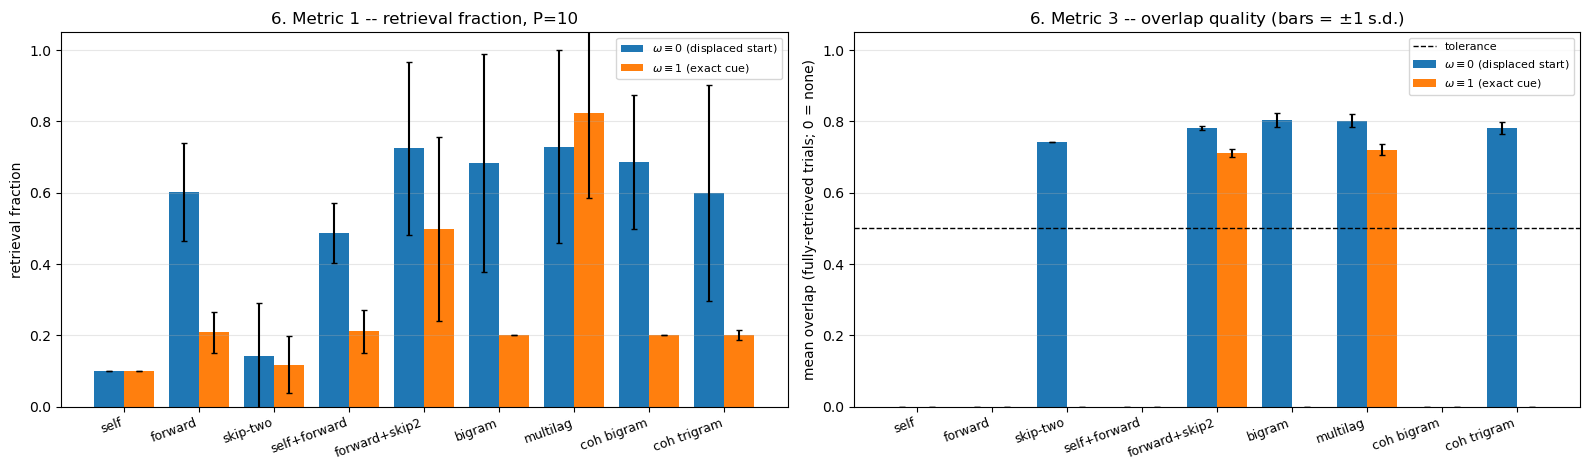

In [19]:
CUE_DISPLACEMENT_RATE = CONFIG["corruption_rate"]   # neurons flipped off xi^0
CUE_PHASE_JITTER      = 0.2                         # radians, uniform on [-j, +j]

OMEGA_ZERO   = {"frequency_mean": 0.0, "frequency_std": 0.0}
OMEGA_ONE    = {"frequency_mean": 1.0, "frequency_std": 0.0}

freq_zero_results = single_sequence_score_sweep(
    RAW_CATALOGUE, seq_len=SEQ_LEN, corruption_rate=CONFIG["corruption_rate"], N=N,
    config_overrides=OMEGA_ZERO,
    cue_corruption_rate=CUE_DISPLACEMENT_RATE, cue_phase_jitter=CUE_PHASE_JITTER,
)

freq_one_results = single_sequence_score_sweep(
    RAW_CATALOGUE, seq_len=SEQ_LEN, corruption_rate=CONFIG["corruption_rate"], N=N,
    config_overrides=OMEGA_ONE,
)

def report(title, results):
    print(title)
    for name, r in results.items():
        q = (f"{r['mean_overlap']:+.3f} +/- {r['overlap_std']:.3f}"
             if r["mean_overlap"] == r["mean_overlap"] else "n/a (none correct)")
        print(f"  {name:<15} fraction={r['retrieval_fraction']:>5.0%}  "
              f"strict={r['retrieval_rate']:>5.0%}   overlap={q}")

report(f"(a) omega = 0, omega_std = 0 -- started from a displacement of xi^0 "
       f"({CUE_DISPLACEMENT_RATE:.0%} flips + {CUE_PHASE_JITTER} rad jitter; not a stored pattern)",
       freq_zero_results)
print()
report("(b) omega = 1, omega_std = 0 -- exact cue, no displacement needed", freq_one_results)

names = list(RAW_CATALOGUE)
x = np.arange(len(names))
CASES = [(freq_zero_results, r"$\omega \equiv 0$ (displaced start)", -0.2),
         (freq_one_results,  r"$\omega \equiv 1$ (exact cue)",       +0.2)]

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
for results, label, off in CASES:
    axes[0].bar(x + off, [results[n]["retrieval_fraction"] for n in names], 0.4, label=label,
                yerr=[results[n]["fraction_std"] for n in names], capsize=2)
    axes[1].bar(x + off, zeroed([results[n]["mean_overlap"] for n in names]), 0.4, label=label,
                yerr=zeroed([results[n]["overlap_std"] for n in names]), capsize=2)
axes[0].set_ylabel("retrieval fraction")
axes[0].set_title(f"6. Metric 1 -- retrieval fraction, P={SEQ_LEN + 1}")
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_ylabel("mean overlap (fully-retrieved trials; 0 = none)")
axes[1].set_title("6. Metric 3 -- overlap quality (bars = $\\pm 1$ s.d.)")
for ax in axes:
    ax.set_xticks(x, names, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


### The retrieval time series from a displaced start ($\omega \equiv 0$)

One run per rule. The trajectory starts from the displacement (dotted line at $t = 0$ -- note
it does not begin at overlap 1, because the start is *off* $\xi^0$), pulls in onto $\xi^0$,
then walks the chain. With no frequency disorder, how far the peaks stay above `tolerance`
before the cascade runs out of drive is what caps the success rate above.


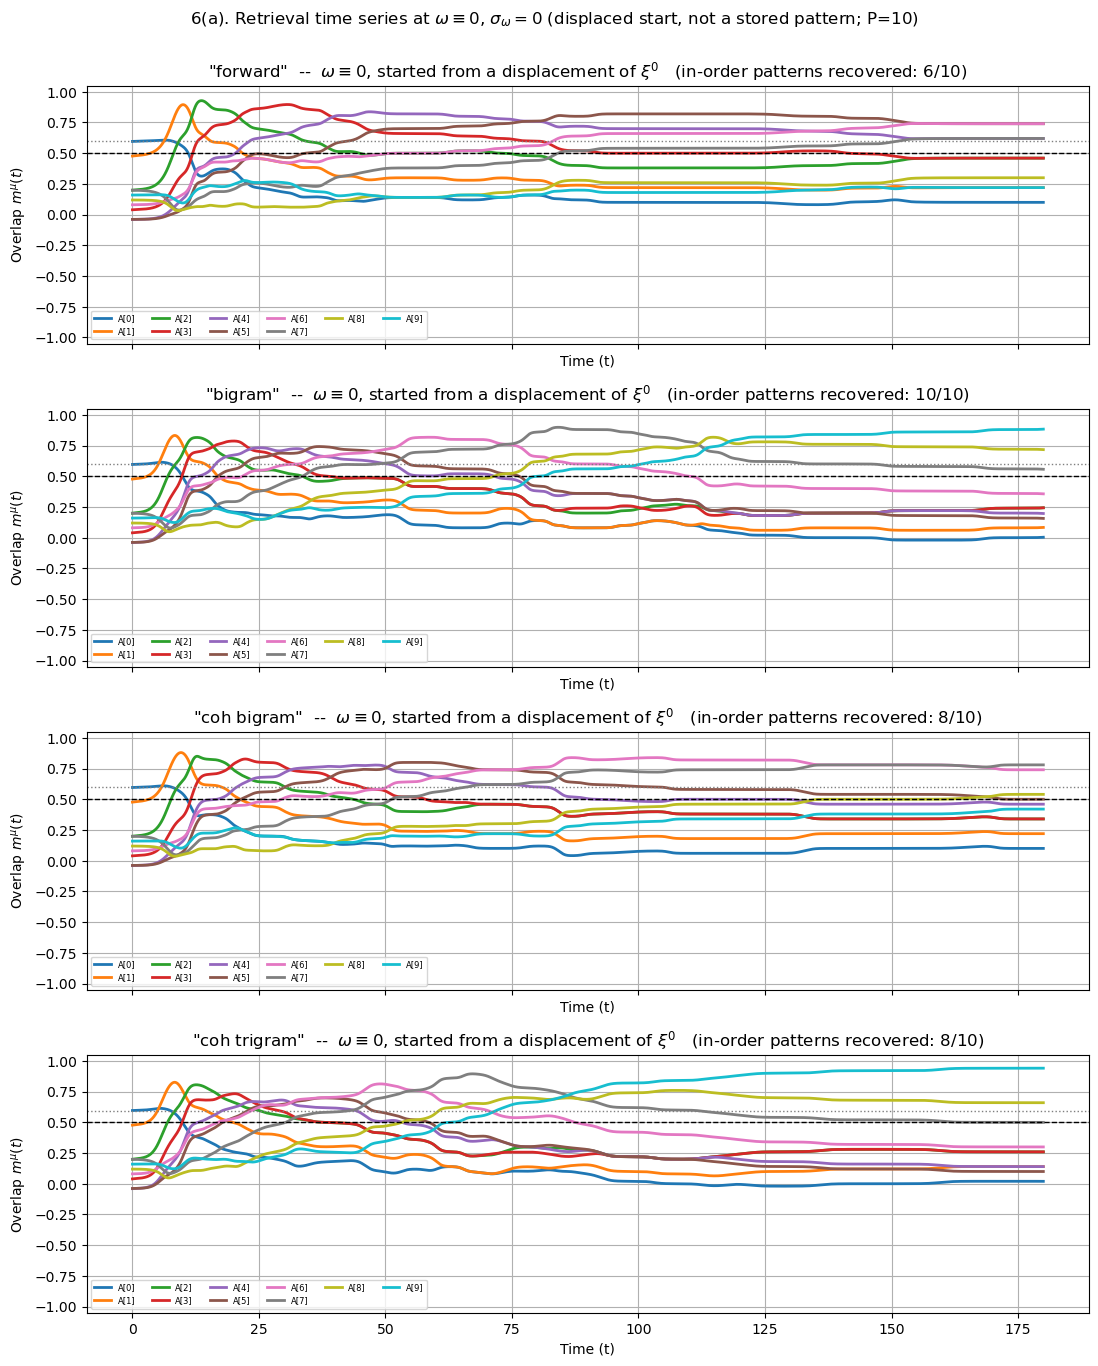

In [20]:
OMEGA_ZERO_EXAMPLE_RULES = ["forward", "bigram", "coh bigram", "coh trigram"]
OMEGA_ZERO_EXAMPLE_SEED = 0

fig, axes = plt.subplots(len(OMEGA_ZERO_EXAMPLE_RULES), 1,
                         figsize=(11, 3.4 * len(OMEGA_ZERO_EXAMPLE_RULES)), sharex=True)
duration = DWELL_PER_TRANSITION * SEQ_LEN

for ax, name in zip(axes, OMEGA_ZERO_EXAMPLE_RULES):
    net = kc.ContextNetwork(rule=RAW_CATALOGUE[name], N=N, seed=10, **{**CONFIG, **OMEGA_ZERO})
    rng = np.random.default_rng(OMEGA_ZERO_EXAMPLE_SEED)
    seq = krm.generate_sequence(N, SEQ_LEN, CONFIG["corruption_rate"], name="A",
                                seed=OMEGA_ZERO_EXAMPLE_SEED)
    result = run_single_trial(net, seq, duration,
                              cue_corruption_rate=CUE_DISPLACEMENT_RATE,
                              cue_phase_jitter=CUE_PHASE_JITTER, rng=rng)
    retrieved = net.decode_sequence_online(result, seq, margin=MARGIN)
    reached = net.compare_to_stored_sequence(retrieved, seq)

    net.plot(result, seq, ax=ax,
             title=f'"{name}"  --  $\\omega \\equiv 0$, started from a displacement of $\\xi^0$'
                   f'   (in-order patterns recovered: {reached}/{len(seq)})')
    ax.axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
    ax.axhline(result["overlaps"][0].max(), color="tab:grey", ls=":", lw=1)
    ax.set_ylim(-1.05, 1.05)
    ax.legend(fontsize=6, ncol=6)

fig.suptitle(r"6(a). Retrieval time series at $\omega \equiv 0$, $\sigma_\omega = 0$ "
             f"(displaced start, not a stored pattern; P={SEQ_LEN + 1})", y=1.001)
plt.tight_layout(); plt.show()


### The same chains at $\omega \equiv 1$ (exact cue)

The other half of §6, drawn the same way. Same rules and the same generation seed as 6(a), so
the stored chain is identical and the only things that differ are $\omega$ and the cue.

No displacement is needed here: at the exact cue $\sin\theta = 0$, but $\omega = 1 \neq 0$, so
the trajectory leaves immediately on its own. Read against 6(a), this is what the displacement
was standing in for.

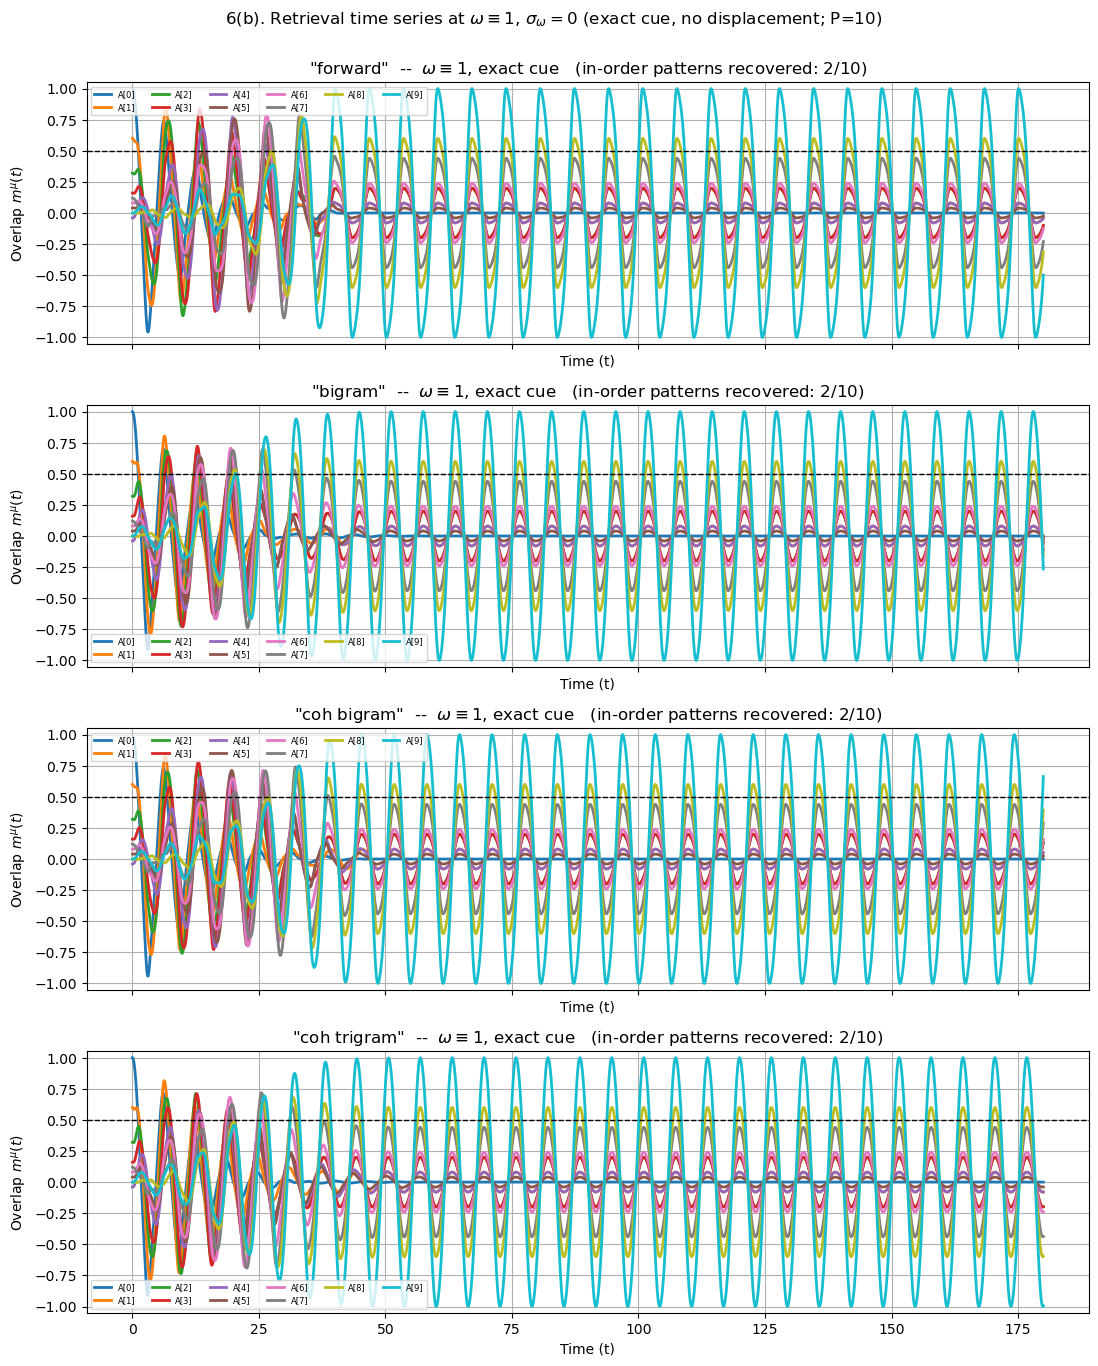

In [21]:
fig, axes = plt.subplots(len(OMEGA_ZERO_EXAMPLE_RULES), 1,
                         figsize=(11, 3.4 * len(OMEGA_ZERO_EXAMPLE_RULES)), sharex=True)
duration = DWELL_PER_TRANSITION * SEQ_LEN

for ax, name in zip(axes, OMEGA_ZERO_EXAMPLE_RULES):
    net = kc.ContextNetwork(rule=RAW_CATALOGUE[name], N=N, seed=10, **{**CONFIG, **OMEGA_ONE})
    seq = krm.generate_sequence(N, SEQ_LEN, CONFIG["corruption_rate"], name="A",
                                seed=OMEGA_ZERO_EXAMPLE_SEED)
    result = net.simulate(seq, T=duration)
    retrieved = net.decode_sequence_online(result, seq, margin=MARGIN)
    reached = net.compare_to_stored_sequence(retrieved, seq)

    net.plot(result, seq, ax=ax,
             title=f'"{name}"  --  $\\omega \\equiv 1$, exact cue'
                   f'   (in-order patterns recovered: {reached}/{len(seq)})')
    ax.axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
    ax.set_ylim(-1.05, 1.05)
    ax.legend(fontsize=6, ncol=6)

fig.suptitle(r"6(b). Retrieval time series at $\omega \equiv 1$, $\sigma_\omega = 0$ "
             f"(exact cue, no displacement; P={SEQ_LEN + 1})", y=1.001)
plt.tight_layout(); plt.show()

---

# 7. Random (uncorrelated) patterns instead of a mutation chain ($\omega \equiv 0.05$)

Every sequence tested so far is a mutation chain: pattern $\mu{+}1$ is a corrupted copy of
$\mu$, so consecutive patterns are similar by construction. This asks the more basic question
that assumes an answer to: does retrieval depend on that similarity at all? Here the stored
sequence is `seq_len+1` **independently random** patterns (`generate_random_sequence`), 20
seeds.

Run for **both** catalogues, since §2 showed the gain correction is what separates
"under-driven" from "cannot do it". Here it changes nothing: peak overlaps sit at 0.16-0.19
against `tolerance = 0.5` either way. On a smooth chain the raw context rules have the right
drive direction and too little of it; on uncorrelated patterns there is no overlap for the
drive to build on, and scaling a gate that reads $m \approx 0$ scales nothing.

Random (uncorrelated) patterns, P=10, 20 seeds (tolerance = 0.5)
rule                   raw frac raw peak        gain frac gain peak
self                 10% +/-0.00    -0.01          10% +/-0.00     -0.01
forward              45% +/-0.20     0.51          45% +/-0.20      0.51
skip-two             10% +/-0.00     0.39          10% +/-0.00      0.39
self+forward         72% +/-0.32     0.63          64% +/-0.30      0.55
forward+skip2        16% +/-0.12     0.50          15% +/-0.09      0.39
bigram               20% +/-0.00     0.39          21% +/-0.04      0.48
multilag             29% +/-0.10     0.52          21% +/-0.03      0.48
coh bigram           23% +/-0.08     0.45          26% +/-0.11      0.50
coh trigram          21% +/-0.03     0.32          20% +/-0.00      0.46


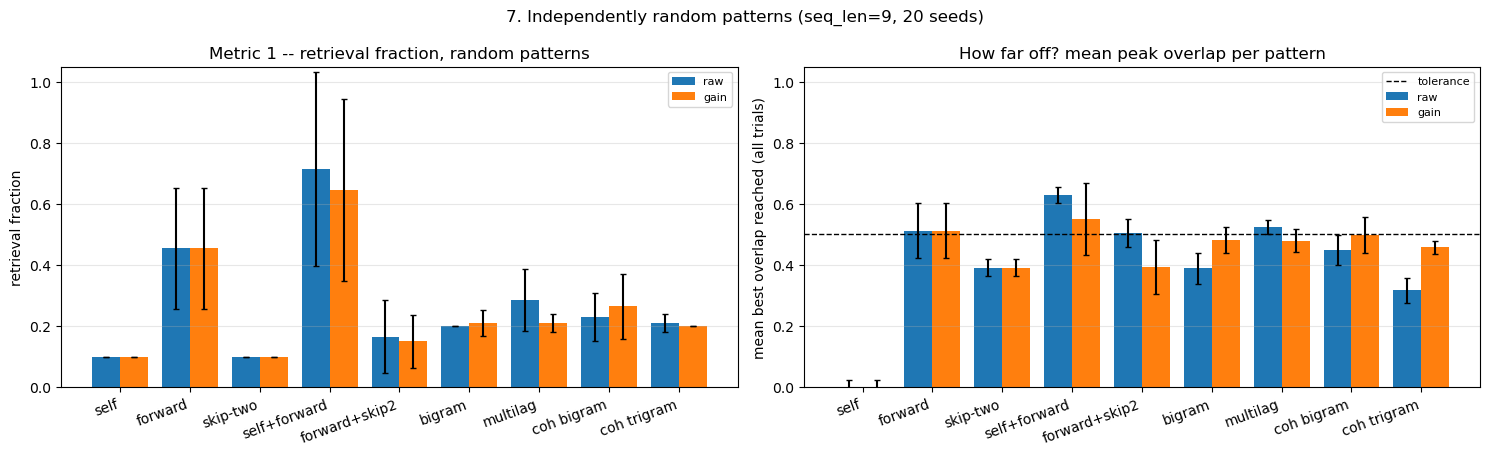

In [22]:
RANDOM_TRIALS = 20

random_results = {
    tag: single_sequence_score_sweep(catalogue, seq_len=SEQ_LEN,
                                     corruption_rate=CONFIG["corruption_rate"],
                                     N=N, trials=RANDOM_TRIALS, random_patterns=True)
    for tag, catalogue in (("raw", RAW_CATALOGUE), ("gain", GAIN_CATALOGUE))
}

# highest overlap reached on any non-cue pattern, regardless of outcome -- with 0% success
# everywhere, metric 2 is undefined and this is what says how far off the rules actually are
def best_reached(catalogue, trials=RANDOM_TRIALS, seed=0):
    rng = np.random.default_rng(seed)
    out = {}
    for name, rule in catalogue.items():
        net = kc.ContextNetwork(rule=rule, N=N, seed=10, **CONFIG)
        vals = []
        for _ in range(trials):
            seq = generate_random_sequence(N, SEQ_LEN, name="A", seed=int(rng.integers(SEED_POOL)))
            result = net.simulate(seq, T=DWELL_PER_TRANSITION * SEQ_LEN)
            vals.append(float(result["overlaps"][:, 1:].max(axis=0).mean()))
        out[name] = (float(np.mean(vals)), float(np.std(vals)))
    return out

reached = {tag: best_reached(cat) for tag, cat in (("raw", RAW_CATALOGUE), ("gain", GAIN_CATALOGUE))}

print(f"Random (uncorrelated) patterns, P={SEQ_LEN + 1}, {RANDOM_TRIALS} seeds "
      f"(tolerance = {CONFIG['tolerance']})")
print(f"{'rule':<15}{'raw frac':>16}{'raw peak':>9}{'gain frac':>17}{'gain peak':>10}")
for name in RAW_CATALOGUE:
    r, gn = random_results["raw"][name], random_results["gain"][name]
    print(f"{name:<15}{r['retrieval_fraction']:>9.0%} +/-{r['fraction_std']:<5.2f}{reached['raw'][name][0]:>8.2f}"
          f"{gn['retrieval_fraction']:>13.0%} +/-{gn['fraction_std']:<5.2f}{reached['gain'][name][0]:>9.2f}")

names = list(RAW_CATALOGUE)
x = np.arange(len(names))
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for off, tag in ((-0.2, "raw"), (0.2, "gain")):
    axes[0].bar(x + off, [random_results[tag][n]["retrieval_fraction"] for n in names], 0.4,
                yerr=[random_results[tag][n]["fraction_std"] for n in names], capsize=2, label=tag)
    axes[1].bar(x + off, [reached[tag][n][0] for n in names], 0.4,
                yerr=[reached[tag][n][1] for n in names], capsize=2, label=tag)
axes[0].set_ylabel("retrieval fraction")
axes[0].set_title("Metric 1 -- retrieval fraction, random patterns")
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_ylabel("mean best overlap reached (all trials)")
axes[1].set_title("How far off? mean peak overlap per pattern")
for ax in axes:
    ax.set_xticks(x, names, rotation=20, ha="right"); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)
fig.suptitle(f"7. Independently random patterns (seq_len={SEQ_LEN}, {RANDOM_TRIALS} seeds)")
plt.tight_layout(); plt.show()


### A few example trajectories

`retrieval_rate=0%` across the board is a strong claim -- worth seeing directly rather than
only as a number. Below: one random-pattern sequence each for a spread of rules (simplest
to most context-heavy), cued from `seq[0]`, plotting overlap with every stored pattern over
time.


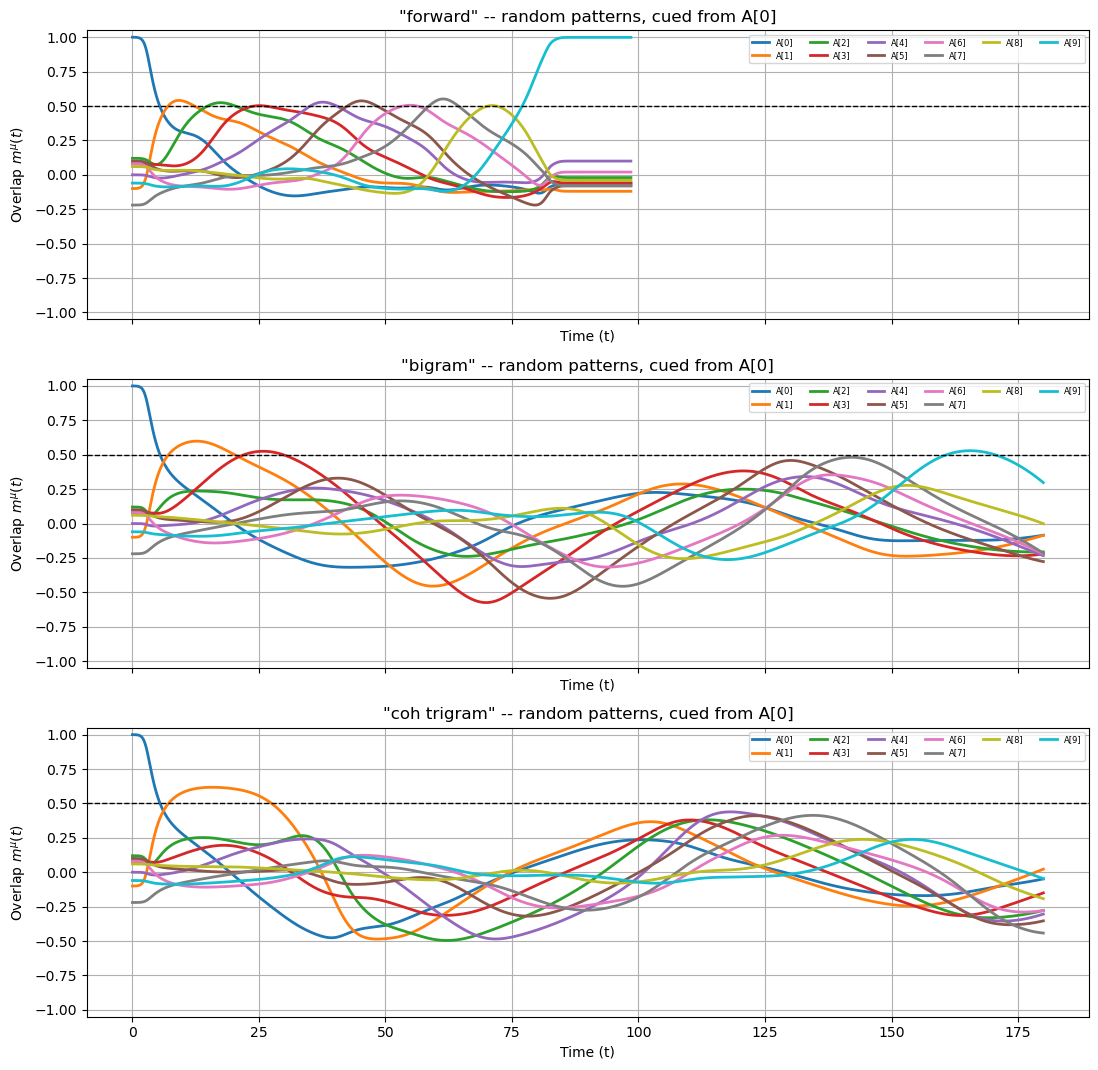

In [23]:
EXAMPLE_RULES = ["forward", "bigram", "coh trigram"]

fig, axes = plt.subplots(len(EXAMPLE_RULES), 1, figsize=(11, 3.6 * len(EXAMPLE_RULES)), sharex=True)
for ax, name in zip(axes, EXAMPLE_RULES):
    net = kc.ContextNetwork(rule=RAW_CATALOGUE[name], N=N, seed=10, **CONFIG)
    seq = generate_random_sequence(N, seq_len=SEQ_LEN, name="A", seed=0)
    result = net.simulate(seq, T=DWELL_PER_TRANSITION * SEQ_LEN)
    net.plot(result, seq, ax=ax, title=f'"{name}" -- random patterns, cued from A[0]')
    ax.axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
    ax.set_ylim(-1.05, 1.05)
    ax.legend(fontsize=6, ncol=6)
plt.tight_layout(); plt.show()


---

# Findings

*(to be filled in from the executed results above)*

## Where to change things

- **Which rules are compared** -- `RAW_CATALOGUE`.
- **Sequence length / integration time** -- `SEQ_LEN` and `DWELL_PER_TRANSITION`; duration is
  always `DWELL_PER_TRANSITION * seq_len` unless a call passes `duration=` explicitly.
- **Crossover topologies** -- `CROSSOVER_GEOMETRIES` (`seq_len`, `shared_idx`, `duration`). The
  shared run must be contiguous with at least one unshared pattern on each side, and
  `make_crossover_pair` builds two branches.
- **The displaced start** -- `CUE_DISPLACEMENT_RATE` and `CUE_PHASE_JITTER`. The jitter must
  stay > 0 at $\omega \equiv 0$ or the start is an exact fixed point.
- **Statistics** -- `SINGLE_SEQ_TRIALS`.